#  Modell 1: Rezeptionsbasiertes Clustering mit ganzem Dataset

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.cluster import MiniBatchKMeans
import warnings
warnings.filterwarnings('ignore')

In [69]:
merged = pd.read_csv('../Dataset/merged_clean.csv')

In [70]:
print("Loading full dataset...")
merged["main_genre"] = merged["genre"].str.split(",").str[0].str.strip()
top_genres = merged["main_genre"].value_counts().head(6).index
df = merged[merged["main_genre"].isin(top_genres)]
df = df[["scoreSentiment", "main_genre",
         "audienceScore", "tomatoMeter"]].dropna().reset_index(drop=True)

Loading full dataset...


In [71]:
print(f"Full dataset: {len(df):,} reviews")
print(f"Genres: {list(df['main_genre'].unique())}")

Full dataset: 838,348 reviews
Genres: ['Comedy', 'Drama', 'Documentary', 'Mystery & thriller', 'Action', 'Horror']


In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.cluster import MiniBatchKMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Paths
BASE_DIR = Path.cwd().parent
DATA_DIR = BASE_DIR / "Dataset"

In [73]:
%matplotlib inline

In [74]:
genre_list   = sorted(df["main_genre"].unique())
genre_colors = ["#4C72B0","#DD8452","#55A868","#C44E52","#8172B2","#937860"]
genre_color  = {g: genre_colors[i] for i, g in enumerate(genre_list)}

GENRE-BASED ANALYSIS

In [75]:
print(""" Das Modell clustert nur anhand von audienceScore und tomatoMeter. Genre ist hier kein Feature des Clustering-Modells. Es wird in Teil 1 nur zur deskriptiven Analyse und in Plot 6 zur Interpretation der Cluster verwendet.""")
print(" " + "="*55)
print("PART 1: Genre-based Analysis")

 Das Modell clustert nur anhand von audienceScore und tomatoMeter. Genre ist hier kein Feature des Clustering-Modells. Es wird in Teil 1 nur zur deskriptiven Analyse und in Plot 6 zur Interpretation der Cluster verwendet.
PART 1: Genre-based Analysis


In [76]:
genre_profiles = df.groupby("main_genre").agg(
    audienceScore      =("audienceScore", "mean"),
    tomatoMeter        =("tomatoMeter",   "mean"),
    positive_pct       =("scoreSentiment", lambda x: 100*(x=="POSITIVE").mean()),
    critic_audience_gap=("audienceScore",  lambda x:
                         x.mean() - df.loc[x.index, "tomatoMeter"].mean()),
    n=("audienceScore", "count")
).reset_index().sort_values("tomatoMeter", ascending=False)

In [77]:
genre_profiles["negative_pct"] = 100 - genre_profiles["positive_pct"]
sorted_genres = genre_profiles["main_genre"].values

In [78]:
print("Genre profiles:")
print(genre_profiles.round(1).to_string(index=False))

Genre profiles:
        main_genre  audienceScore  tomatoMeter  positive_pct  critic_audience_gap      n  negative_pct
       Documentary           76.7         86.5          86.4                 -9.8 100583          13.6
             Drama           69.2         73.1          73.1                 -3.8 244304          26.9
            Comedy           62.2         63.2          63.3                 -0.9 219270          36.7
Mystery & thriller           59.1         61.4          61.5                 -2.3  89861          38.5
            Horror           53.6         61.1          61.5                 -7.5  81113          38.5
            Action           65.7         58.0          58.1                  7.7 103217          41.9


# Plot 1 : Scores per genre

 Plot 1: Scores per Genre 


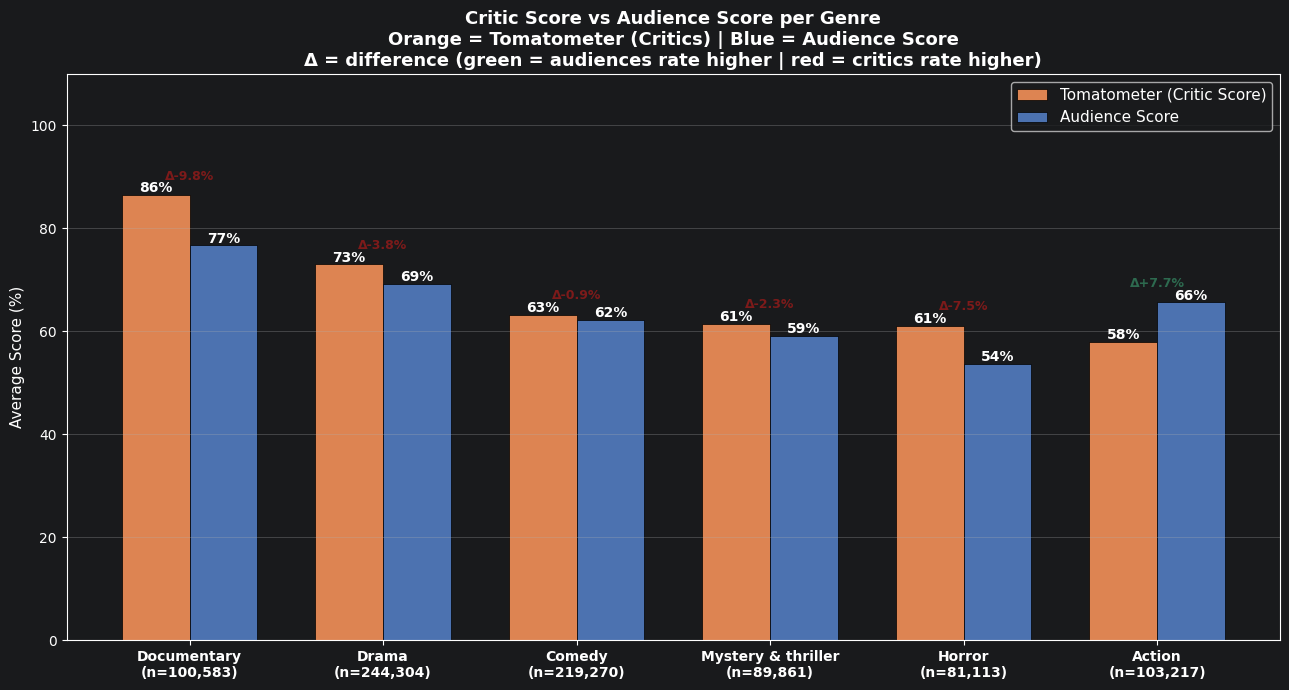

In [79]:
print(" Plot 1: Scores per Genre ")
fig, ax = plt.subplots(figsize=(13, 7))
aud_vals = [genre_profiles[genre_profiles["main_genre"]==g]["audienceScore"].values[0]
            for g in sorted_genres]
tom_vals = [genre_profiles[genre_profiles["main_genre"]==g]["tomatoMeter"].values[0]
            for g in sorted_genres]
n_vals   = [genre_profiles[genre_profiles["main_genre"]==g]["n"].values[0]
            for g in sorted_genres]
x     = np.arange(len(sorted_genres))
width = 0.35
bars1 = ax.bar(x - width / 2, tom_vals, width,
               label="Tomatometer (Critic Score)",
               color="#DD8452", edgecolor="black", linewidth=0.5)
bars2 = ax.bar(x + width / 2, aud_vals, width,
               label="Audience Score",
               color="#4C72B0", edgecolor="black", linewidth=0.5)
for bar, val in zip(bars1, tom_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f"{val:.0f}%", ha="center", fontsize=10, fontweight="bold")
for bar, val in zip(bars2, aud_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f"{val:.0f}%", ha="center", fontsize=10, fontweight="bold")
for i, (tom, aud) in enumerate(zip(tom_vals, aud_vals)):
    diff = aud - tom
    color = "#2d6a4f" if diff > 0 else "#7d1a1a"
    ax.annotate(f"Δ{diff:+.1f}%",
                xy=(i, max(tom, aud) + 3),
                ha="center", fontsize=9,
                color=color, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(
    [f"{g}\n(n={n:,})" for g, n in zip(sorted_genres, n_vals)],
    fontsize=10, fontweight="bold")
ax.set_title("Critic Score vs Audience Score per Genre\n"
             "Orange = Tomatometer (Critics) | Blue = Audience Score\n"
             "Δ = difference (green = audiences rate higher | red = critics rate higher)",
             fontweight="bold", fontsize=13)
ax.set_ylabel("Average Score (%)", fontsize=11)
ax.set_ylim(0, 110)
ax.legend(fontsize=11, loc="upper right")
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.savefig("plot1_scores_per_genre.png", dpi=150, bbox_inches="tight")
plt.show()

# Plot 2 : Positive vs Negative

 Plot 2: Positive vs Negative 


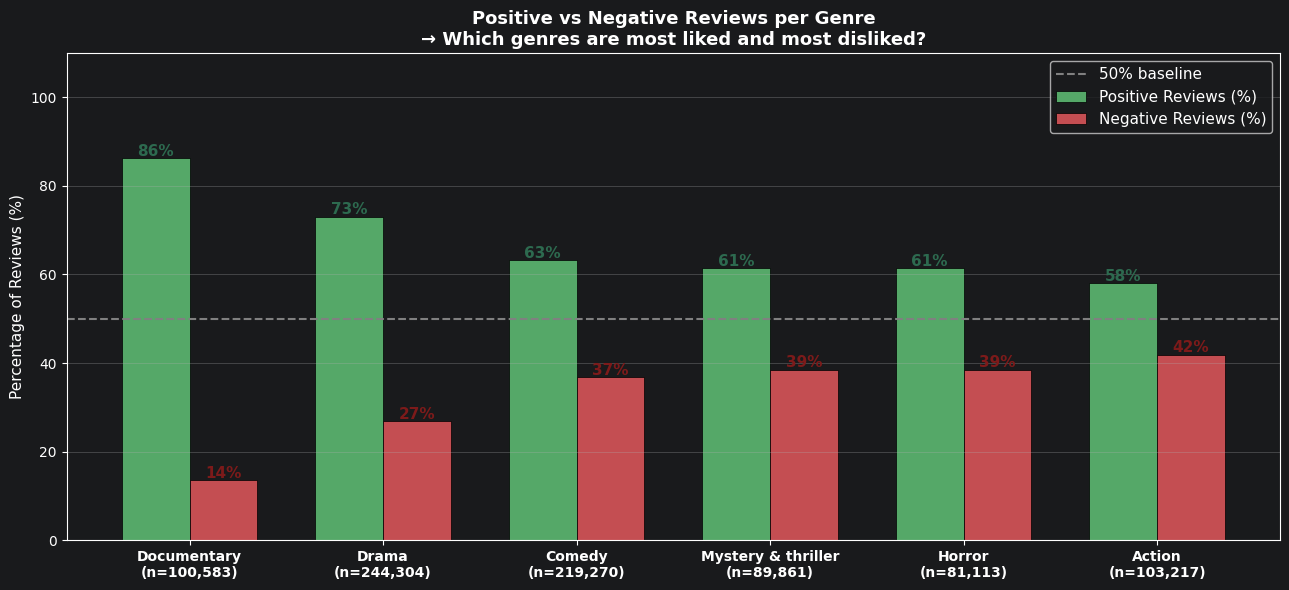

In [80]:
print(" Plot 2: Positive vs Negative ")
fig, ax = plt.subplots(figsize=(13, 6))
pos_vals = [genre_profiles[genre_profiles["main_genre"] == g]
            ["positive_pct"].values[0] for g in sorted_genres]
neg_vals = [100 - p for p in pos_vals]
x = np.arange(len(sorted_genres))
width = 0.35
bars1 = ax.bar(x - width / 2, pos_vals, width,
               label="Positive Reviews (%)",
               color="#55A868", edgecolor="black", linewidth=0.5)
bars2 = ax.bar(x + width / 2, neg_vals, width,
               label="Negative Reviews (%)",
               color="#C44E52", edgecolor="black", linewidth=0.5)
for bar, val in zip(bars1, pos_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f"{val:.0f}%", ha="center", fontsize=11,
            fontweight="bold", color="#2d6a4f")
for bar, val in zip(bars2, neg_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f"{val:.0f}%", ha="center", fontsize=11,
            fontweight="bold", color="#7d1a1a")
ax.axhline(50, color="gray", linestyle="--",
           linewidth=1.5, label="50% baseline")
ax.set_xticks(x)
ax.set_xticklabels(
    [f"{g}\n(n={genre_profiles[genre_profiles['main_genre'] == g]['n'].values[0]:,})"
     for g in sorted_genres],
    fontsize=10, fontweight="bold")
ax.set_title("Positive vs Negative Reviews per Genre\n"
             "→ Which genres are most liked and most disliked?",
             fontweight="bold", fontsize=13)
ax.set_ylabel("Percentage of Reviews (%)", fontsize=11)
ax.set_ylim(0, 110)
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.savefig("plot2_positive_negative.png", dpi=150, bbox_inches="tight")
plt.show()

# Plot 3: Genre Heatmap

 Plot 3: Genre Heatmap 


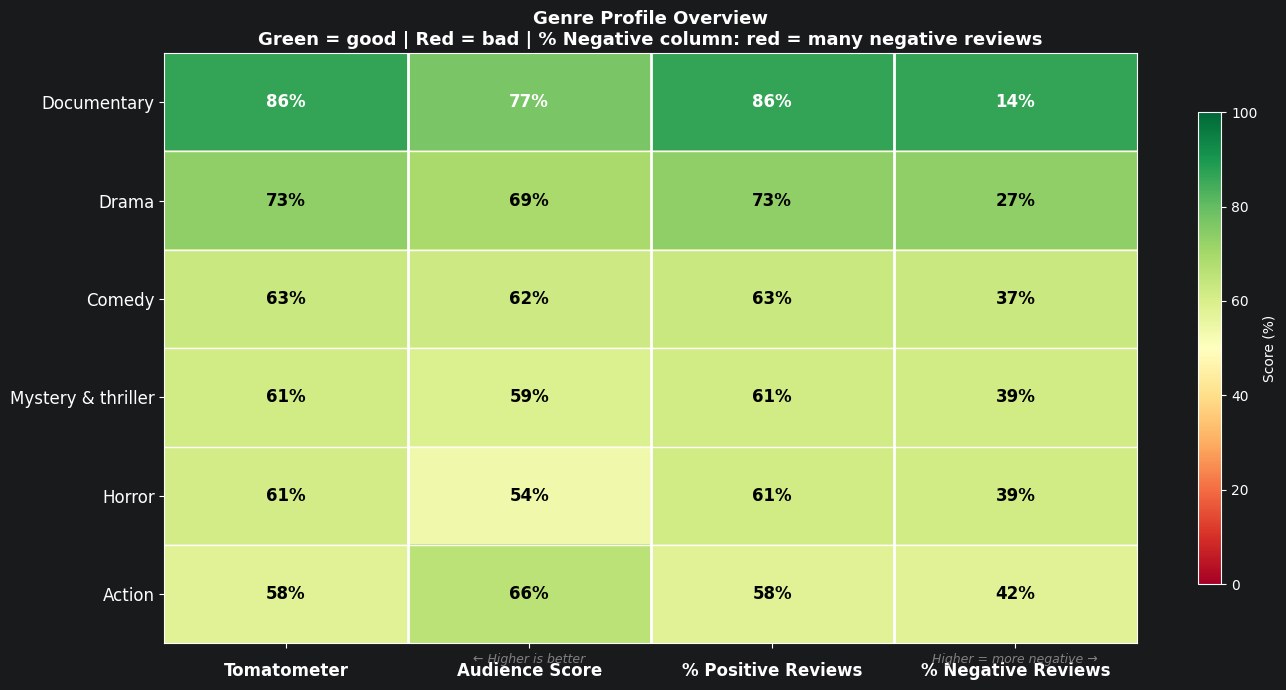

In [81]:
print(" Plot 3: Genre Heatmap ")
heatmap_cols = ["tomatoMeter", "audienceScore",
                "positive_pct", "negative_pct"]
heatmap_labels = ["Tomatometer", "Audience Score",
                  "% Positive Reviews", "% Negative Reviews"]
heatmap_data = genre_profiles.set_index("main_genre").loc[
    sorted_genres, heatmap_cols].values
display_data = heatmap_data.copy()
display_data[:, 3] = 100 - display_data[:, 3]
fig, ax = plt.subplots(figsize=(14, 7))
im = ax.imshow(display_data, cmap="RdYlGn",
               aspect="auto", vmin=0, vmax=100)
ax.set_xticks(range(len(heatmap_labels)))
ax.set_xticklabels(heatmap_labels, fontsize=12, fontweight="bold")
ax.tick_params(axis='x', pad=10)
ax.set_yticks(range(len(sorted_genres)))
ax.set_yticklabels(sorted_genres, fontsize=12)
for i in range(len(sorted_genres)):
    for j in range(len(heatmap_labels)):
        val = heatmap_data[i, j]
        disp_val = display_data[i, j]
        color = "black" if 25 < disp_val < 75 else "white"
        ax.text(j, i, f"{val:.0f}%",
                ha="center", va="center",
                fontsize=12, fontweight="bold", color=color)
for x_pos in [0.5, 1.5, 2.5]:
    ax.axvline(x_pos, color="white", linewidth=2)
for y_pos in np.arange(0.5, len(sorted_genres) - 0.5, 1):
    ax.axhline(y_pos, color="white", linewidth=1)
ax.annotate("← Higher is better",
            xy=(1.0, len(sorted_genres) - 0.3),
            xycoords=("data", "data"),
            ha="center", fontsize=9,
            color="gray", style="italic")
ax.annotate("Higher = more negative →",
            xy=(3.0, len(sorted_genres) - 0.3),
            xycoords=("data", "data"),
            ha="center", fontsize=9,
            color="gray", style="italic")
plt.colorbar(im, ax=ax, label="Score (%)", shrink=0.8)
ax.set_title("Genre Profile Overview\n"
             "Green = good | Red = bad | "
             "% Negative column: red = many negative reviews",
             fontweight="bold", fontsize=13)
plt.subplots_adjust(left=0.18)
plt.tight_layout()
plt.savefig("plot3_genre_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

ML CLUSTERING

In [82]:
print(" " + "="*55)
print("PART 2: ML Clustering")

PART 2: ML Clustering


In [83]:
features = df[["audienceScore", "tomatoMeter"]].values
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(features)

In [84]:
print("Evaluating k values...")
sil_scores = []
db_scores  = []
k_range    = range(2, 8)

Evaluating k values...


In [85]:
for k in k_range:
    mbk    = MiniBatchKMeans(n_clusters=k, random_state=42,
                              batch_size=10000, n_init=10)
    labels = mbk.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels, sample_size=10000))
    db_scores.append(davies_bouldin_score(X_scaled, labels))
    print(f"  k={k}: Silhouette={sil_scores[-1]:.3f}, DB={db_scores[-1]:.3f}")

  k=2: Silhouette=0.515, DB=0.739
  k=3: Silhouette=0.428, DB=0.908
  k=4: Silhouette=0.445, DB=0.850
  k=5: Silhouette=0.393, DB=0.933
  k=6: Silhouette=0.372, DB=0.871
  k=7: Silhouette=0.378, DB=0.890


In [86]:
best_k_auto = list(k_range)[np.argmax(sil_scores)]
best_k = 4
print(f"Mathematisch optimales k (Silhouette): {best_k_auto}")
print(f"Gewähltes k = {best_k} — gleiche Begründung wie auf den Folien: "
      f"vier inhaltlich klar interpretierbare Rezeptionsklassen "
      f"(Poorly/Below/Above/Well Received)")

Mathematisch optimales k (Silhouette): 2
Gewähltes k = 4 — gleiche Begründung wie auf den Folien: vier inhaltlich klar interpretierbare Rezeptionsklassen (Poorly/Below/Above/Well Received)


In [87]:
mbk_final = MiniBatchKMeans(n_clusters=best_k, random_state=42,
                             batch_size=10000, n_init=10)
df["cluster"] = mbk_final.fit_predict(X_scaled) + 1

In [88]:
cluster_means = df.groupby("cluster")[["audienceScore","tomatoMeter"]].mean()
cluster_pos   = df.groupby("cluster")["scoreSentiment"].apply(
    lambda x: 100*(x=="POSITIVE").mean())

In [89]:
cluster_name_map = {}
for cid in cluster_means.index:
    tom = cluster_means.loc[cid, "tomatoMeter"]
    if tom < 35:
        cluster_name_map[cid] = "Poorly Received"
    elif tom < 55:
        cluster_name_map[cid] = "Below Average"
    elif tom < 75:
        cluster_name_map[cid] = "Above Average"
    else:
        cluster_name_map[cid] = "Well Received"

In [90]:
name_counts = pd.Series(list(cluster_name_map.values())).value_counts()
if name_counts.max() > 1:
    for cid in cluster_means.index:
        tom = cluster_means.loc[cid, "tomatoMeter"]
        aud = cluster_means.loc[cid, "audienceScore"]
        cluster_name_map[cid] = (
            f"Cluster {cid}\n"
            f"Tomato:{tom:.0f}% | Audience:{aud:.0f}%")

In [91]:
df["cluster_name"] = df["cluster"].map(cluster_name_map)
cluster_order  = [cluster_name_map[i]
                  for i in sorted(cluster_name_map.keys(),
                                  key=lambda x: cluster_means.loc[x,"tomatoMeter"])]
cluster_colors = ["#C44E52","#DD8452","#F5C518","#55A868"]

In [92]:
sil = silhouette_score(X_scaled, df["cluster"].values, sample_size=10000)
db  = davies_bouldin_score(X_scaled, df["cluster"].values)
print(f"Silhouette: {sil:.3f} | Davies-Bouldin: {db:.3f}")

Silhouette: 0.442 | Davies-Bouldin: 0.850


In [93]:
print("Cluster profiles:")
for cname in cluster_order:
    n   = (df["cluster_name"]==cname).sum()
    tom = df[df["cluster_name"]==cname]["tomatoMeter"].mean()
    aud = df[df["cluster_name"]==cname]["audienceScore"].mean()
    pos = 100*(df[df["cluster_name"]==cname]["scoreSentiment"]=="POSITIVE").mean()
    print(f"  {cname.split(chr(10))[0]}: "
          f"n={n:,} | tomato={tom:.0f}% | audience={aud:.0f}% | positive={pos:.0f}%")

Cluster profiles:
  Poorly Received: n=161,496 | tomato=28% | audience=39% | positive=28%
  Below Average: n=142,071 | tomato=53% | audience=72% | positive=53%
  Above Average: n=178,140 | tomato=74% | audience=51% | positive=74%
  Well Received: n=356,641 | tomato=89% | audience=82% | positive=89%


# Plot 4: Evaluation Metrics

Plot 4: Evaluation Metrics 


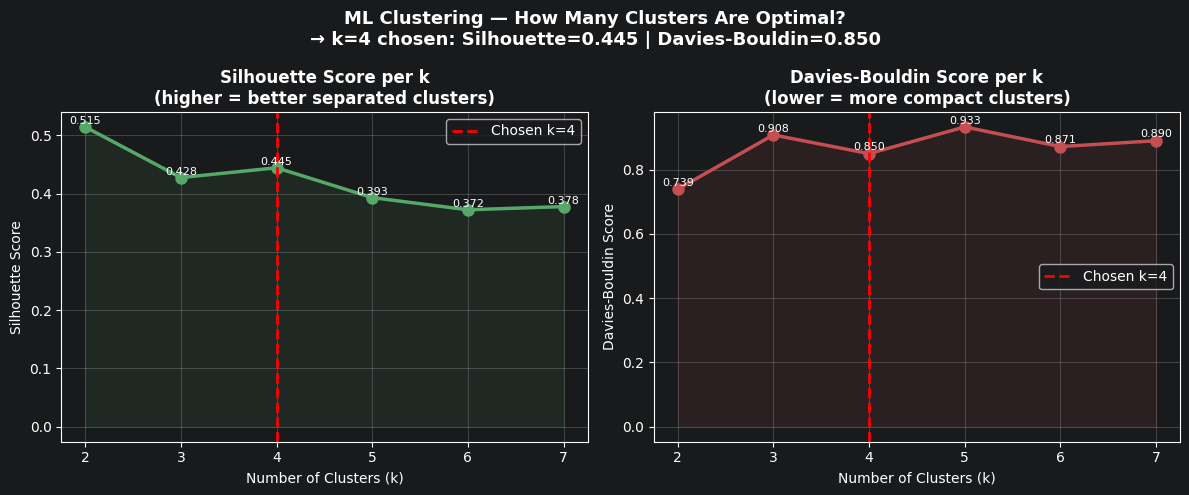

In [94]:

print("Plot 4: Evaluation Metrics ")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.plot(k_range, sil_scores, marker='o', color="#55A868",
         linewidth=2.5, markersize=8)
ax1.fill_between(k_range, sil_scores, alpha=0.1, color="#55A868")
ax1.axvline(best_k, color="red", linestyle="--", linewidth=2,
            label=f"Chosen k={best_k}")
for k, s in zip(k_range, sil_scores):
    ax1.text(k, s + 0.005, f"{s:.3f}", ha="center", fontsize=8)
ax1.set_title("Silhouette Score per k\n(higher = better separated clusters)",
              fontweight="bold", fontsize=12)
ax1.set_xlabel("Number of Clusters (k)")
ax1.set_ylabel("Silhouette Score")
ax1.legend()
ax1.grid(alpha=0.4)
ax2.plot(k_range, db_scores, marker='o', color="#C44E52",
         linewidth=2.5, markersize=8)
ax2.fill_between(k_range, db_scores, alpha=0.1, color="#C44E52")
ax2.axvline(best_k, color="red", linestyle="--", linewidth=2,
            label=f"Chosen k={best_k}")
for k, d in zip(k_range, db_scores):
    ax2.text(k, d + 0.01, f"{d:.3f}", ha="center", fontsize=8)
ax2.set_title("Davies-Bouldin Score per k\n(lower = more compact clusters)",
              fontweight="bold", fontsize=12)
ax2.set_xlabel("Number of Clusters (k)")
ax2.set_ylabel("Davies-Bouldin Score")
ax2.legend()
ax2.grid(alpha=0.4)
fig.suptitle(f"ML Clustering — How Many Clusters Are Optimal?\n"
             f"→ k={best_k} chosen: Silhouette={sil_scores[best_k - 2]:.3f} | "
             f"Davies-Bouldin={db_scores[best_k - 2]:.3f}",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("plot4_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()

# Plot 5: Cluster Profiles

Plot 5: Cluster Profiles


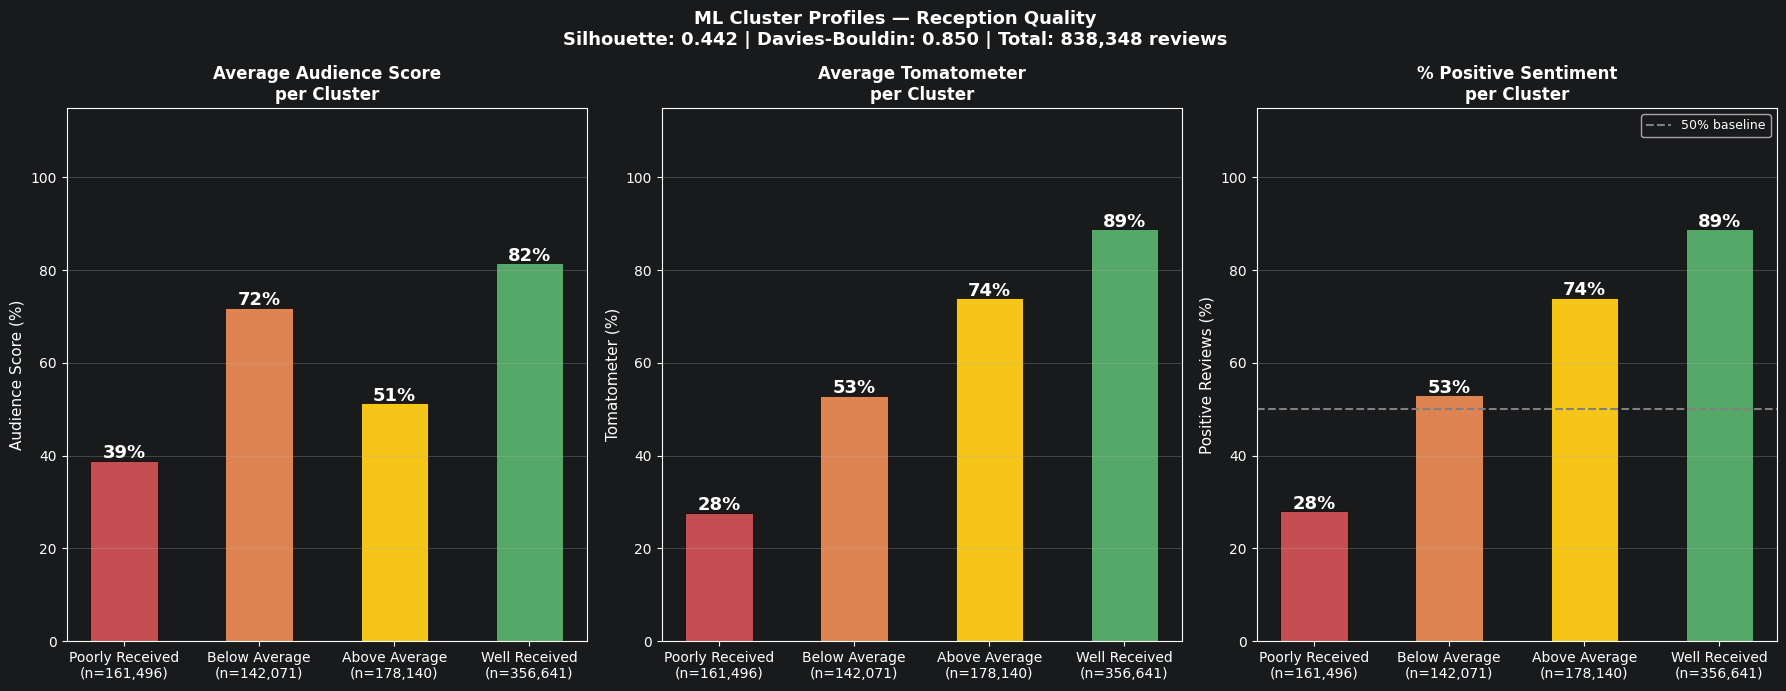

In [95]:
print("Plot 5: Cluster Profiles")
aud_vals = [df[df["cluster_name"] == c]["audienceScore"].mean()
            for c in cluster_order]
tom_vals = [df[df["cluster_name"] == c]["tomatoMeter"].mean()
            for c in cluster_order]
pos_vals = [100 * (df[df["cluster_name"] == c]["scoreSentiment"] == "POSITIVE").mean()
            for c in cluster_order]
neg_vals = [100 - p for p in pos_vals]
xticklabels = []
for c in cluster_order:
    n = (df["cluster_name"] == c).sum()
    xticklabels.append(f"{c.split(chr(10))[0]}\n(n={n:,})")
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
for ax, vals, title, ylabel in zip(
        axes,
        [aud_vals, tom_vals, pos_vals],
        ["Average Audience Score\nper Cluster",
         "Average Tomatometer\nper Cluster",
         "% Positive Sentiment\nper Cluster"],
        ["Audience Score (%)", "Tomatometer (%)", "Positive Reviews (%)"]):

    bars = ax.bar(range(len(cluster_order)), vals,
                  color=cluster_colors, edgecolor="black",
                  linewidth=0.5, width=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f"{val:.0f}%", ha="center", fontweight="bold", fontsize=13)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontweight="bold", fontsize=12)
    ax.set_ylim(0, 115)
    ax.set_xticks(range(len(cluster_order)))
    ax.set_xticklabels(xticklabels, rotation=0, ha="center", fontsize=10)
    ax.grid(axis="y", alpha=0.4)
    if "Sentiment" in title:
        ax.axhline(50, color="gray", linestyle="--",
                   linewidth=1.5, label="50% baseline")
        ax.legend(fontsize=9)
fig.suptitle(f"ML Cluster Profiles — Reception Quality\n"
             f"Silhouette: {sil:.3f} | Davies-Bouldin: {db:.3f} | "
             f"Total: {len(df):,} reviews",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("plot5_cluster_profiles.png", dpi=150, bbox_inches="tight")
plt.show()

# Plot 6: clusters vs Genre

Plot 6: Scatter Plot 


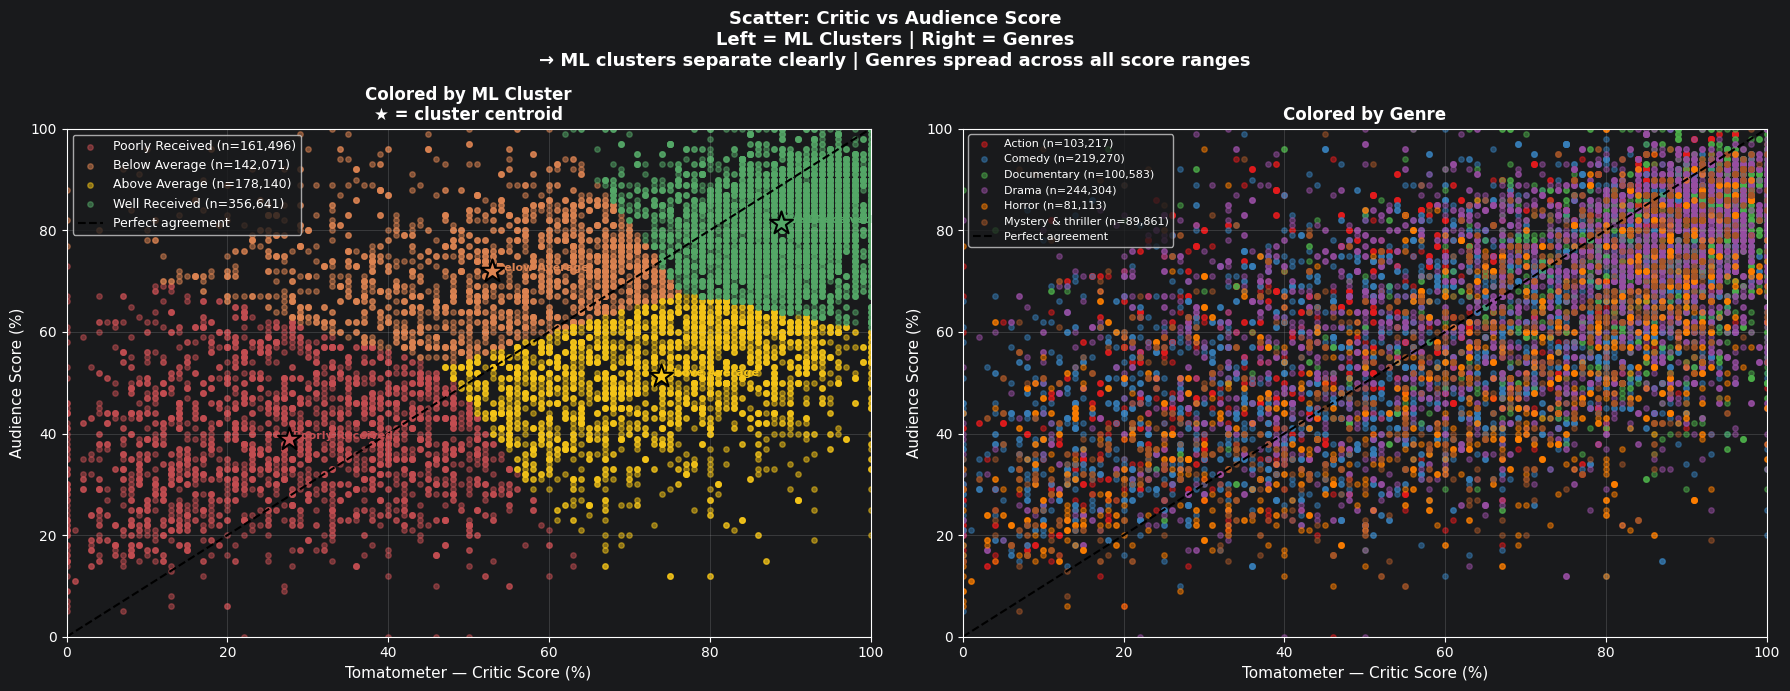

In [96]:
print("Plot 6: Scatter Plot ")
scatter_sample = df.sample(n=15000, random_state=42)
distinct_genre_colors = ["#e41a1c", "#377eb8", "#4daf4a",
                         "#984ea3", "#ff7f00", "#a65628"]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
for i, cname in enumerate(cluster_order):
    mask = scatter_sample["cluster_name"] == cname
    n = (df["cluster_name"] == cname).sum()
    ax1.scatter(
        scatter_sample[mask]["tomatoMeter"],
        scatter_sample[mask]["audienceScore"],
        c=cluster_colors[i], alpha=0.5, s=15,
        label=f"{cname.split(chr(10))[0]} (n={n:,})")
for i, cname in enumerate(cluster_order):
    cid = [k for k, v in cluster_name_map.items() if v == cname][0]
    tom = cluster_means.loc[cid, "tomatoMeter"]
    aud = cluster_means.loc[cid, "audienceScore"]
    ax1.scatter(tom, aud, c=cluster_colors[i], s=300,
                marker="*", edgecolor="black", linewidth=1.5, zorder=5)
    ax1.annotate(f" {cname.split(chr(10))[0]}",
                 (tom, aud), fontsize=8, fontweight="bold",
                 color=cluster_colors[i])
ax1.plot([0, 100], [0, 100], color="black", linestyle="--",
         linewidth=1.5, label="Perfect agreement")
ax1.set_title("Colored by ML Cluster\n★ = cluster centroid",
              fontweight="bold", fontsize=12)
ax1.set_xlabel("Tomatometer — Critic Score (%)", fontsize=11)
ax1.set_ylabel("Audience Score (%)", fontsize=11)
ax1.set_xlim(0, 100)
ax1.set_ylim(0, 100)
ax1.legend(fontsize=9, loc="upper left")
ax1.grid(alpha=0.3)
for i, genre in enumerate(genre_list):
    mask = scatter_sample["main_genre"] == genre
    n = (df["main_genre"] == genre).sum()
    ax2.scatter(
        scatter_sample[mask]["tomatoMeter"],
        scatter_sample[mask]["audienceScore"],
        c=distinct_genre_colors[i], alpha=0.5, s=15,
        label=f"{genre} (n={n:,})")
ax2.plot([0, 100], [0, 100], color="black", linestyle="--",
         linewidth=1.5, label="Perfect agreement")
ax2.set_title("Colored by Genre",
              fontweight="bold", fontsize=12)
ax2.set_xlabel("Tomatometer — Critic Score (%)", fontsize=11)
ax2.set_ylabel("Audience Score (%)", fontsize=11)
ax2.set_xlim(0, 100)
ax2.set_ylim(0, 100)
ax2.legend(fontsize=8, loc="upper left")
ax2.grid(alpha=0.3)
fig.suptitle("Scatter: Critic vs Audience Score\n"
             "Left = ML Clusters | Right = Genres\n"
             "→ ML clusters separate clearly | Genres spread across all score ranges",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("plot6_scatter_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


def evaluate_k_range(X_scaled, k_range=range(2, 8), sample_size=10000):
    sil_scores, db_scores = [], []
    for k in k_range:
        mbk = MiniBatchKMeans(n_clusters=k, random_state=42,
                              batch_size=10000, n_init=10)
        labels = mbk.fit_predict(X_scaled)
        sil_scores.append(silhouette_score(X_scaled, labels, sample_size=sample_size))
        db_scores.append(davies_bouldin_score(X_scaled, labels))
        print(f"  k={k}: Silhouette={sil_scores[-1]:.3f}, DB={db_scores[-1]:.3f}")
    return sil_scores, db_scores


SUMMARY

In [97]:
print(" " + "="*55)
print("FULL DATASET CLUSTERING SUMMARY")


FULL DATASET CLUSTERING SUMMARY


In [98]:
print("PART 1: Genre Analysis ")
print(f"Total reviews: {len(df):,}")
for _, row in genre_profiles.iterrows():
    gap       = row["audienceScore"] - row["tomatoMeter"]
    direction = "audiences rate higher" if gap > 0 else "critics rate higher"
    print(f"  {row['main_genre']}: tomato={row['tomatoMeter']:.0f}%, "
          f"audience={row['audienceScore']:.0f}%, "
          f"positive={row['positive_pct']:.0f}%, "
          f"negative={row['negative_pct']:.0f}%, "
          f"gap={gap:+.1f}% ({direction})")

PART 1: Genre Analysis 
Total reviews: 838,348
  Documentary: tomato=86%, audience=77%, positive=86%, negative=14%, gap=-9.8% (critics rate higher)
  Drama: tomato=73%, audience=69%, positive=73%, negative=27%, gap=-3.8% (critics rate higher)
  Comedy: tomato=63%, audience=62%, positive=63%, negative=37%, gap=-0.9% (critics rate higher)
  Mystery & thriller: tomato=61%, audience=59%, positive=61%, negative=39%, gap=-2.3% (critics rate higher)
  Horror: tomato=61%, audience=54%, positive=61%, negative=39%, gap=-7.5% (critics rate higher)
  Action: tomato=58%, audience=66%, positive=58%, negative=42%, gap=+7.7% (audiences rate higher)


In [99]:
print(" PART 2: ML Clustering ")
print(f"Algorithm:      MiniBatchKMeans")
print(f"Features:       audienceScore, tomatoMeter")
print(f"Total reviews:  {len(df):,}")
print(f"Clusters:       {best_k}")
print(f"Silhouette:     {sil:.3f}")
print(f"Davies-Bouldin: {db:.3f}")
for cname in cluster_order:
    n   = (df["cluster_name"]==cname).sum()
    tom = df[df["cluster_name"]==cname]["tomatoMeter"].mean()
    aud = df[df["cluster_name"]==cname]["audienceScore"].mean()
    pos = 100*(df[df["cluster_name"]==cname]["scoreSentiment"]=="POSITIVE").mean()
    neg = 100 - pos
    print(f"  {cname.split(chr(10))[0]}:")
    print(f"    n              = {n:,}")
    print(f"    Tomatometer    = {tom:.0f}%")
    print(f"    Audience Score = {aud:.0f}%")
    print(f"    Positive       = {pos:.0f}%")
    print(f"    Negative       = {neg:.0f}%")

 PART 2: ML Clustering 
Algorithm:      MiniBatchKMeans
Features:       audienceScore, tomatoMeter
Total reviews:  838,348
Clusters:       4
Silhouette:     0.442
Davies-Bouldin: 0.850
  Poorly Received:
    n              = 161,496
    Tomatometer    = 28%
    Audience Score = 39%
    Positive       = 28%
    Negative       = 72%
  Below Average:
    n              = 142,071
    Tomatometer    = 53%
    Audience Score = 72%
    Positive       = 53%
    Negative       = 47%
  Above Average:
    n              = 178,140
    Tomatometer    = 74%
    Audience Score = 51%
    Positive       = 74%
    Negative       = 26%
  Well Received:
    n              = 356,641
    Tomatometer    = 89%
    Audience Score = 82%
    Positive       = 89%
    Negative       = 11%


In [100]:
print("Done! All 6 plots saved.")

Done! All 6 plots saved.


# Modell 2: Emotionsbasiertes Clustering

In [101]:
merged = pd.read_csv('../Dataset/merged_clean.csv')
emotions = pd.read_csv('../Dataset/classification_sample_100k_with_emotions.csv')

In [102]:
merged["main_genre"] = merged["genre"].str.split(",").str[0].str.strip()
top_genres = merged["main_genre"].value_counts().head(6).index
merged = merged[merged["main_genre"].isin(top_genres)]

In [103]:
df = emotions.merge(
    merged[["reviewId", "main_genre", "audienceScore", "tomatoMeter"]],
    on="reviewId", how="inner")
df = df.dropna(subset=["joy", "anger", "sadness", "fear",
                       "disgust", "surprise", "neutral",
                       "emotional_intensity", "audienceScore",
                       "tomatoMeter", "main_genre"]).reset_index(drop=True)

In [104]:
print(f"Dataset: {len(df):,} reviews")
print(f"Genres: {list(df['main_genre'].unique())}")

Dataset: 63,193 reviews
Genres: ['Comedy', 'Documentary', 'Mystery & thriller', 'Drama', 'Horror', 'Action']


In [105]:
genre_list = sorted(df["main_genre"].unique())
emotions_plot = ["joy", "anger", "sadness", "fear", "disgust", "surprise"]
em_colors = {
    "joy": "#F5C518",
    "anger": "#C44E52",
    "sadness": "#4C72B0",
    "fear": "#8172B2",
    "disgust": "#937860",
    "surprise": "#DD8452"
}
genre_colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2", "#937860"]
genre_color = {g: genre_colors[i] for i, g in enumerate(genre_list)}

In [106]:
print(" " + "=" * 60)
print("PART 1: Genre-based Emotion Analysis")

PART 1: Genre-based Emotion Analysis


In [107]:
genre_emotion = df.groupby("main_genre")[emotions_plot].mean()
genre_scores = df.groupby("main_genre").agg(
    audienceScore=("audienceScore", "mean"),
    tomatoMeter=("tomatoMeter", "mean"),
    positive_pct=("scoreSentiment", lambda x: 100 * (x == "POSITIVE").mean()),
    emotional_intensity=("emotional_intensity", "mean"),
    n=("reviewText", "count")
).reset_index()

In [108]:
print("Genre emotion profiles:")
print(pd.concat([genre_emotion.round(3),
                 genre_scores.set_index("main_genre")[
                     ["tomatoMeter", "positive_pct"]].round(1)], axis=1))

Genre emotion profiles:
                      joy  anger  sadness   fear  disgust  surprise  \
main_genre                                                            
Action              0.251  0.051    0.078  0.048    0.135     0.055   
Comedy              0.294  0.040    0.076  0.044    0.141     0.053   
Documentary         0.218  0.043    0.065  0.081    0.116     0.063   
Drama               0.210  0.042    0.100  0.079    0.127     0.054   
Horror              0.144  0.037    0.066  0.291    0.142     0.050   
Mystery & thriller  0.179  0.045    0.081  0.149    0.142     0.053   

                    tomatoMeter  positive_pct  
main_genre                                     
Action                     57.9          58.2  
Comedy                     63.4          63.4  
Documentary                86.4          86.4  
Drama                      73.1          73.1  
Horror                     60.4          60.7  
Mystery & thriller         61.7          61.3  


# Plot 1 : Emotion scores per genre

 Plot 1: Emotions per Genre 


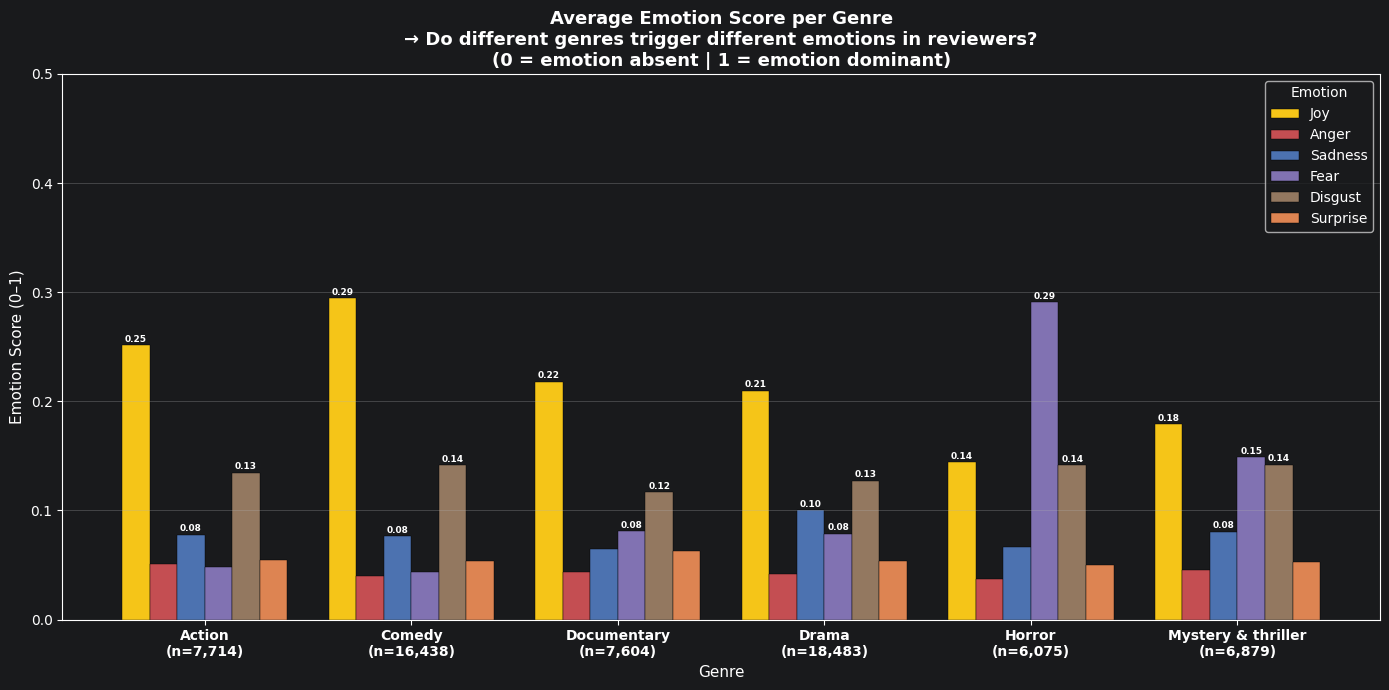

In [109]:
print(" Plot 1: Emotions per Genre ")
fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(genre_list))
width = 0.8 / len(emotions_plot)
offsets = np.linspace(-width * (len(emotions_plot) - 1) / 2,
                      width * (len(emotions_plot) - 1) / 2,
                      len(emotions_plot))
for i, emotion in enumerate(emotions_plot):
    vals = [genre_emotion.loc[g, emotion] for g in genre_list]
    bars = ax.bar(x + offsets[i], vals, width,
                  label=emotion.capitalize(),
                  color=em_colors[emotion],
                  edgecolor="black", linewidth=0.3)
    for bar, val in zip(bars, vals):
        if val > 0.07:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.003,
                    f"{val:.2f}", ha="center",
                    fontsize=6.5, fontweight="bold")
ax.set_title("Average Emotion Score per Genre\n"
             "→ Do different genres trigger different emotions in reviewers?\n"
             "(0 = emotion absent | 1 = emotion dominant)",
             fontweight="bold", fontsize=13)
ax.set_ylabel("Emotion Score (0–1)", fontsize=11)
ax.set_xlabel("Genre", fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(
    [f"{g}\n(n={genre_scores[genre_scores['main_genre'] == g]['n'].values[0]:,})"
     for g in genre_list],
    fontsize=10, fontweight="bold")
ax.set_ylim(0, 0.5)
ax.legend(title="Emotion", fontsize=10, loc="upper right")
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.savefig("plot1_emotions_per_genre.png", dpi=150, bbox_inches="tight")
plt.show()


# Plot 2 : Dominante genre per Emotion

 Plot 2: Dominant Genre per Emotion 


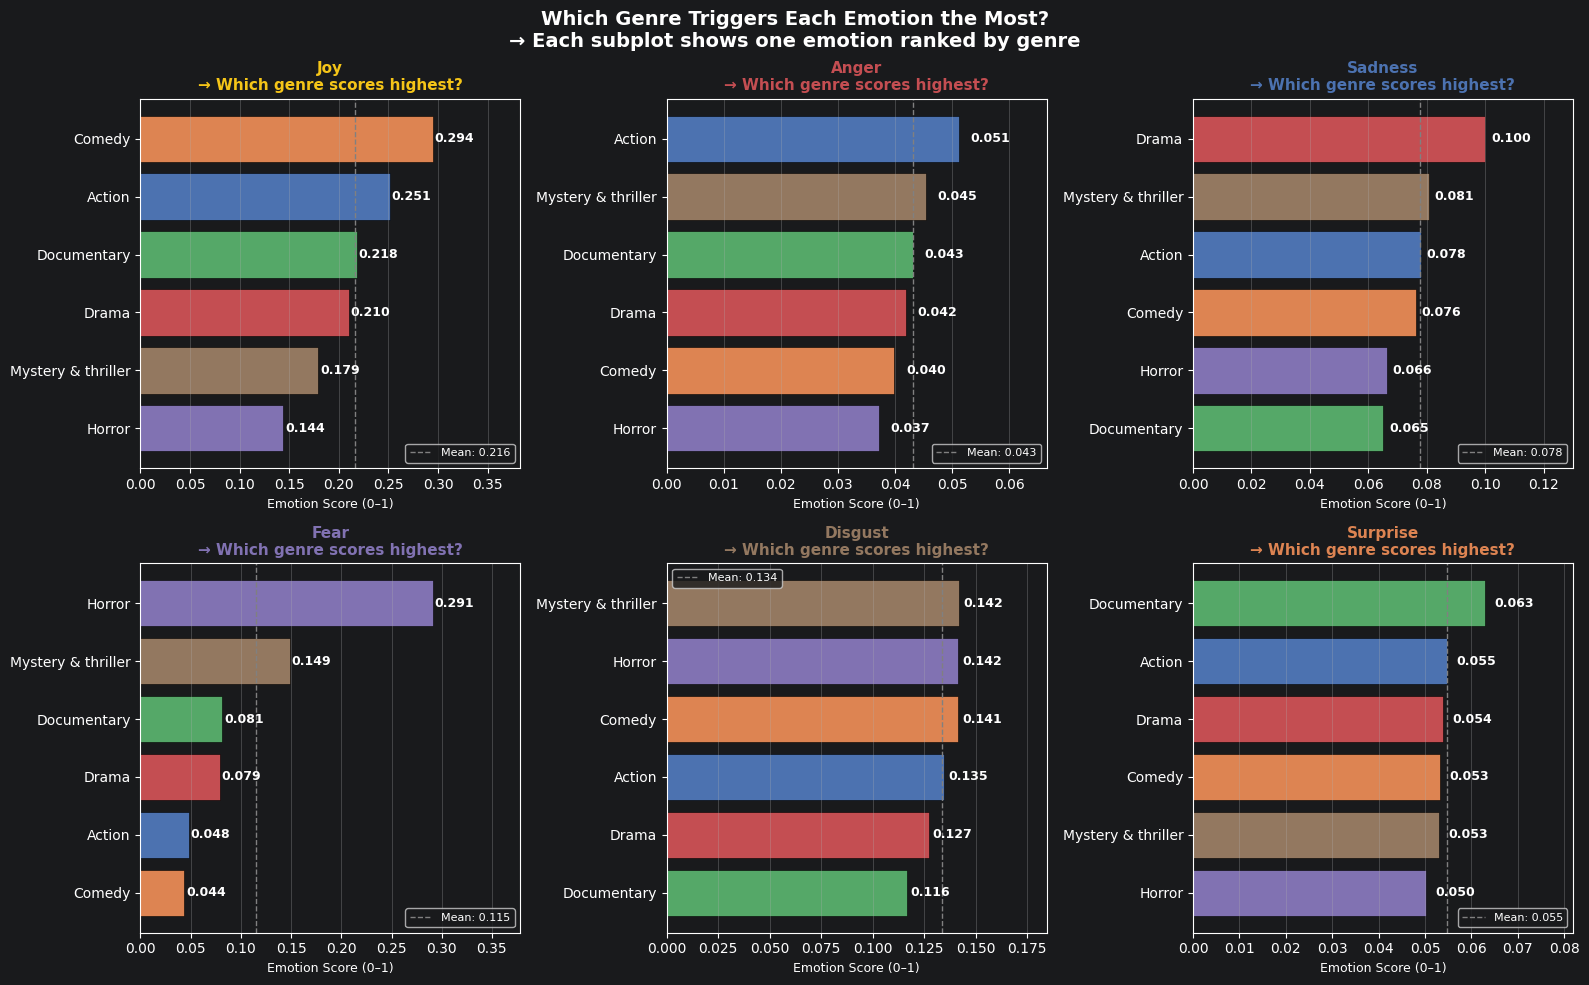

In [110]:
print(" Plot 2: Dominant Genre per Emotion ")
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
for i, emotion in enumerate(emotions_plot):
    vals = [genre_emotion.loc[g, emotion] for g in genre_list]
    colors = [genre_color[g] for g in genre_list]
    sorted_idx = np.argsort(vals)
    sorted_genres = [genre_list[j] for j in sorted_idx]
    sorted_vals = [vals[j] for j in sorted_idx]
    sorted_colors = [colors[j] for j in sorted_idx]

    bars = axes[i].barh(sorted_genres, sorted_vals,
                        color=sorted_colors, edgecolor="black", linewidth=0.4)
    for bar, val in zip(bars, sorted_vals):
        axes[i].text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
                     f"{val:.3f}", va="center", fontsize=9, fontweight="bold")

    axes[i].set_title(f"{emotion.capitalize()}\n"
                      f"→ Which genre scores highest?",
                      fontweight="bold", fontsize=11,
                      color=em_colors[emotion])
    axes[i].set_xlabel("Emotion Score (0–1)", fontsize=9)
    axes[i].set_xlim(0, max(sorted_vals) * 1.3)
    axes[i].grid(axis="x", alpha=0.4)
    axes[i].axvline(np.mean(sorted_vals), color="gray",
                    linestyle="--", linewidth=1,
                    label=f"Mean: {np.mean(sorted_vals):.3f}")
    axes[i].legend(fontsize=8)
fig.suptitle("Which Genre Triggers Each Emotion the Most?\n"
             "→ Each subplot shows one emotion ranked by genre",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("plot2_dominant_genre_per_emotion.png", dpi=150, bbox_inches="tight")
plt.show()

# Plot 3 : Genre Heatmap

 Plot 3: Genre Heatmap 


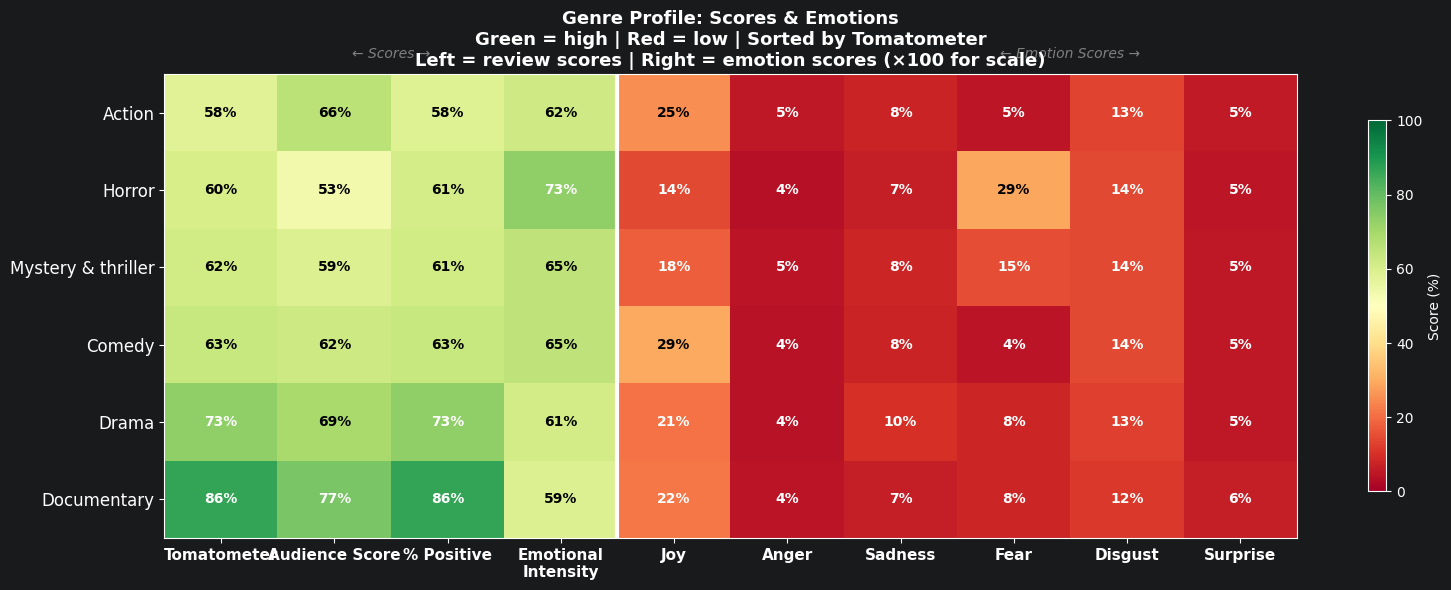

In [111]:
print(" Plot 3: Genre Heatmap ")
heatmap_cols   = ["tomatoMeter", "audienceScore", "positive_pct",
                  "emotional_intensity"]
heatmap_labels = ["Tomatometer", "Audience Score", "% Positive",
                  "Emotional\nIntensity"]
emotion_scaled = genre_emotion * 100
score_data = genre_scores.set_index("main_genre")[heatmap_cols]
score_data["emotional_intensity"] = score_data["emotional_intensity"] * 100
all_data = pd.concat([score_data, emotion_scaled], axis=1)
all_data_sorted = all_data.sort_values("tomatoMeter", ascending=True)
all_labels = heatmap_labels + [e.capitalize() for e in emotions_plot]
fig, ax = plt.subplots(figsize=(16, 6))
im = ax.imshow(all_data_sorted.values, cmap="RdYlGn",
               aspect="auto", vmin=0, vmax=100)
ax.set_xticks(range(len(all_labels)))
ax.set_xticklabels(all_labels, fontsize=11, fontweight="bold")
ax.set_yticks(range(len(all_data_sorted)))
ax.set_yticklabels(all_data_sorted.index, fontsize=12)
for i in range(len(all_data_sorted)):
    for j in range(len(all_labels)):
        val = all_data_sorted.values[i, j]
        color = "black" if 25 < val < 70 else "white"
        ax.text(j, i, f"{val:.0f}%", ha="center", va="center",
                fontsize=10, fontweight="bold", color=color)
ax.axvline(3.5, color="white", linewidth=3)
ax.text(1.5, -0.7, "← Scores →", ha="center", fontsize=10,
        color="gray", style="italic")
ax.text(7.5, -0.7, "← Emotion Scores →", ha="center", fontsize=10,
        color="gray", style="italic")
plt.colorbar(im, ax=ax, label="Score (%)", shrink=0.8)
ax.set_title("Genre Profile: Scores & Emotions\n"
             "Green = high | Red = low | Sorted by Tomatometer\n"
             "Left = review scores | Right = emotion scores (×100 for scale)",
             fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig("plot3_genre_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


# ML CLUSTERING

In [112]:
print(" " + "=" * 60)
print("PART 2: ML Clustering")

PART 2: ML Clustering


In [113]:
feature_cols = ["joy", "anger", "sadness", "fear",
                "disgust", "surprise", "neutral", "emotional_intensity",
                "audienceScore", "tomatoMeter"]
X = df[feature_cols].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [114]:
print(" Evaluating k values...")
sil_scores = []
db_scores = []
k_range = range(2, 9)

 Evaluating k values...


In [115]:
for k in k_range:
    mbk = MiniBatchKMeans(n_clusters=k, random_state=42,
                          batch_size=10000, n_init=10)
    labels = mbk.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels, sample_size=5000))
    db_scores.append(davies_bouldin_score(X_scaled, labels))
    print(f"  k={k}: Silhouette={sil_scores[-1]:.3f}, DB={db_scores[-1]:.3f}")

  k=2: Silhouette=0.154, DB=1.623
  k=3: Silhouette=0.258, DB=1.721
  k=4: Silhouette=0.308, DB=1.513
  k=5: Silhouette=0.314, DB=1.549
  k=6: Silhouette=0.380, DB=1.267
  k=7: Silhouette=0.411, DB=0.898
  k=8: Silhouette=0.317, DB=1.150


In [116]:
best_k_auto = list(k_range)[np.argmax(sil_scores)]
best_k = best_k_auto
print(f"Mathematisch optimales k (Silhouette): {best_k_auto}")
print(f"Gewähltes k = {best_k}")
print(f"""
Begründung für k={best_k}:
- Höchster Silhouette Score über k=2 bis k=8: {max(sil_scores):.3f}
- Niedrigster Davies-Bouldin Score: {min(db_scores):.3f}
- Beide Metriken stimmen überein → k={best_k} ist eindeutig optimal
- Inhaltlich: jede der 7 Emotionen (joy, anger, sadness, fear,
  disgust, surprise, neutral) bildet einen eigenen klar benennbaren Cluster
- k=8 fällt deutlich ab (Silhouette={sil_scores[6]:.3f})
""")

Mathematisch optimales k (Silhouette): 7
Gewähltes k = 7

Begründung für k=7:
- Höchster Silhouette Score über k=2 bis k=8: 0.411
- Niedrigster Davies-Bouldin Score: 0.898
- Beide Metriken stimmen überein → k=7 ist eindeutig optimal
- Inhaltlich: jede der 7 Emotionen (joy, anger, sadness, fear,
  disgust, surprise, neutral) bildet einen eigenen klar benennbaren Cluster
- k=8 fällt deutlich ab (Silhouette=0.317)



# Plot 4: Evaluation Metrics

 Plot 4: Evaluation Metrics 


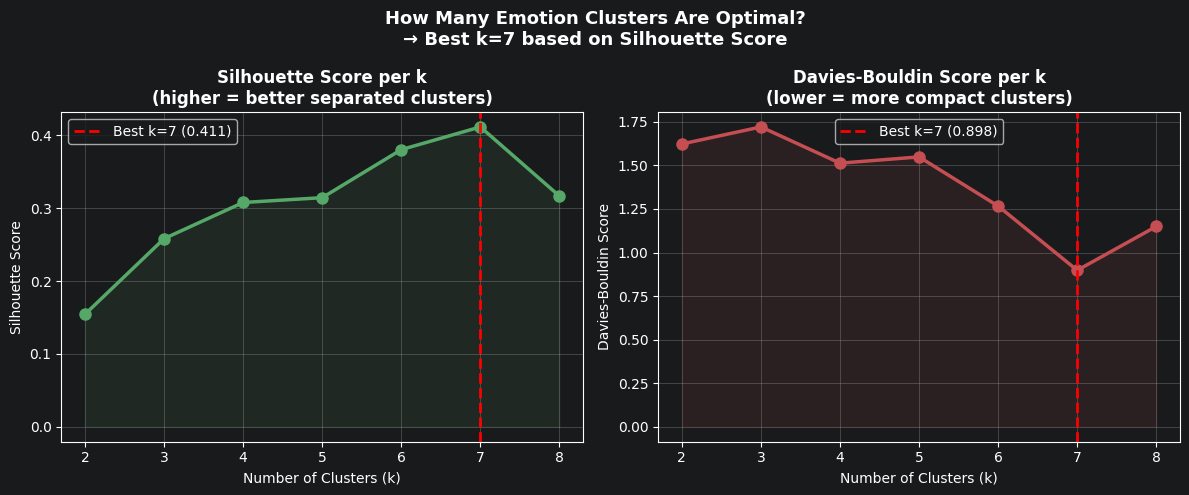

 Training MiniBatchKMeans k={best_k} 
  Cluster 1: dominant=joy (0.747) | tomato=74% | positive=89% | intensity=0.849
  Cluster 2: dominant=fear (0.780) | tomato=70% | positive=74% | intensity=0.919
  Cluster 3: dominant=disgust (0.649) | tomato=56% | positive=42% | intensity=0.850
  Cluster 4: dominant=neutral (0.736) | tomato=68% | positive=66% | intensity=0.264
  Cluster 5: dominant=sadness (0.701) | tomato=65% | positive=50% | intensity=0.878
  Cluster 6: dominant=surprise (0.637) | tomato=69% | positive=69% | intensity=0.843
  Cluster 7: dominant=anger (0.637) | tomato=67% | positive=63% | intensity=0.889
Cluster name check:
cluster_name
Neutral (0.74)\nPositive | Low Intensity\nTomato: 68%      24212
Joy (0.75)\nPositive | High Intensity\nTomato: 74%         15456
Disgust (0.65)\nMixed | High Intensity\nTomato: 56%         8650
Fear (0.78)\nPositive | High Intensity\nTomato: 70%         5729
Sadness (0.70)\nMixed | High Intensity\nTomato: 65%         4617
Surprise (0.64)\nPositiv

In [117]:
print(" Plot 4: Evaluation Metrics ")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.plot(k_range, sil_scores, marker='o', color="#55A868",
         linewidth=2.5, markersize=8)
ax1.fill_between(k_range, sil_scores, alpha=0.1, color="#55A868")
ax1.axvline(best_k, color="red", linestyle="--", linewidth=2,
            label=f"Best k={best_k} ({max(sil_scores):.3f})")
ax1.set_title("Silhouette Score per k\n(higher = better separated clusters)",
              fontweight="bold", fontsize=12)
ax1.set_xlabel("Number of Clusters (k)")
ax1.set_ylabel("Silhouette Score")
ax1.legend()
ax1.grid(alpha=0.4)
best_k_db = list(k_range)[np.argmin(db_scores)]
ax2.plot(k_range, db_scores, marker='o', color="#C44E52",
         linewidth=2.5, markersize=8)
ax2.fill_between(k_range, db_scores, alpha=0.1, color="#C44E52")
ax2.axvline(best_k, color="red", linestyle="--", linewidth=2,
            label=f"Best k={best_k} ({min(db_scores):.3f})")
ax2.set_title("Davies-Bouldin Score per k\n(lower = more compact clusters)",
              fontweight="bold", fontsize=12)
ax2.set_xlabel("Number of Clusters (k)")
ax2.set_ylabel("Davies-Bouldin Score")
ax2.legend()
ax2.grid(alpha=0.4)
fig.suptitle(f"How Many Emotion Clusters Are Optimal?\n"
             f"→ Best k={best_k} based on Silhouette Score",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("plot4_evaluation_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

print(" Training MiniBatchKMeans k={best_k} ")
mbk_final = MiniBatchKMeans(n_clusters=best_k, random_state=42,
                            batch_size=10000, n_init=10)
df["cluster"] = mbk_final.fit_predict(X_scaled) + 1
cluster_means = df.groupby("cluster")[
    ["joy", "anger", "sadness", "fear", "disgust", "surprise", "neutral",
     "emotional_intensity", "audienceScore", "tomatoMeter"]].mean()
cluster_pos = df.groupby("cluster")["scoreSentiment"].apply(
    lambda x: 100 * (x == "POSITIVE").mean())
emotions_with_neutral = ["joy", "anger", "sadness", "fear",
                         "disgust", "surprise", "neutral"]
cluster_name_map = {}
for cid in cluster_means.index:
    dom_emotion = cluster_means.loc[cid, emotions_with_neutral].idxmax()
    dom_val = cluster_means.loc[cid, emotions_with_neutral].max()
    tom = cluster_means.loc[cid, "tomatoMeter"]
    pos = cluster_pos[cid]
    ei = cluster_means.loc[cid, "emotional_intensity"]

    reception = "Positive" if pos >= 60 else \
        "Negative" if pos < 40 else "Mixed"
    intensity = "High" if ei > 0.7 else \
        "Medium" if ei > 0.4 else "Low"

    cluster_name_map[cid] = (
        f"{dom_emotion.capitalize()} ({dom_val:.2f})\n"
        f"{reception} | {intensity} Intensity\n"
        f"Tomato: {tom:.0f}%")

    print(f"  Cluster {cid}: dominant={dom_emotion} ({dom_val:.3f}) | "
          f"tomato={tom:.0f}% | positive={pos:.0f}% | intensity={ei:.3f}")
df["cluster_name"] = df["cluster"].map(cluster_name_map)
print("Cluster name check:")
print(df["cluster_name"].value_counts())
missing = df["cluster_name"].isnull().sum()
print("Missing names: {missing}")
cluster_order = [cluster_name_map[i]
                 for i in sorted(cluster_name_map.keys(),
                                 key=lambda x: cluster_means.loc[x, "tomatoMeter"])]
cmap_colors = plt.cm.tab10(np.linspace(0, 1, best_k))
cluster_colors = [cmap_colors[i] for i in range(best_k)]
sil_final = silhouette_score(X_scaled, df["cluster"].values, sample_size=5000)
db_final = davies_bouldin_score(X_scaled, df["cluster"].values)
print(f"Silhouette: {sil_final:.3f} | Davies-Bouldin: {db_final:.3f}")

# Plot 5 : Cluster profiles

 Plot 5: Cluster Profiles 


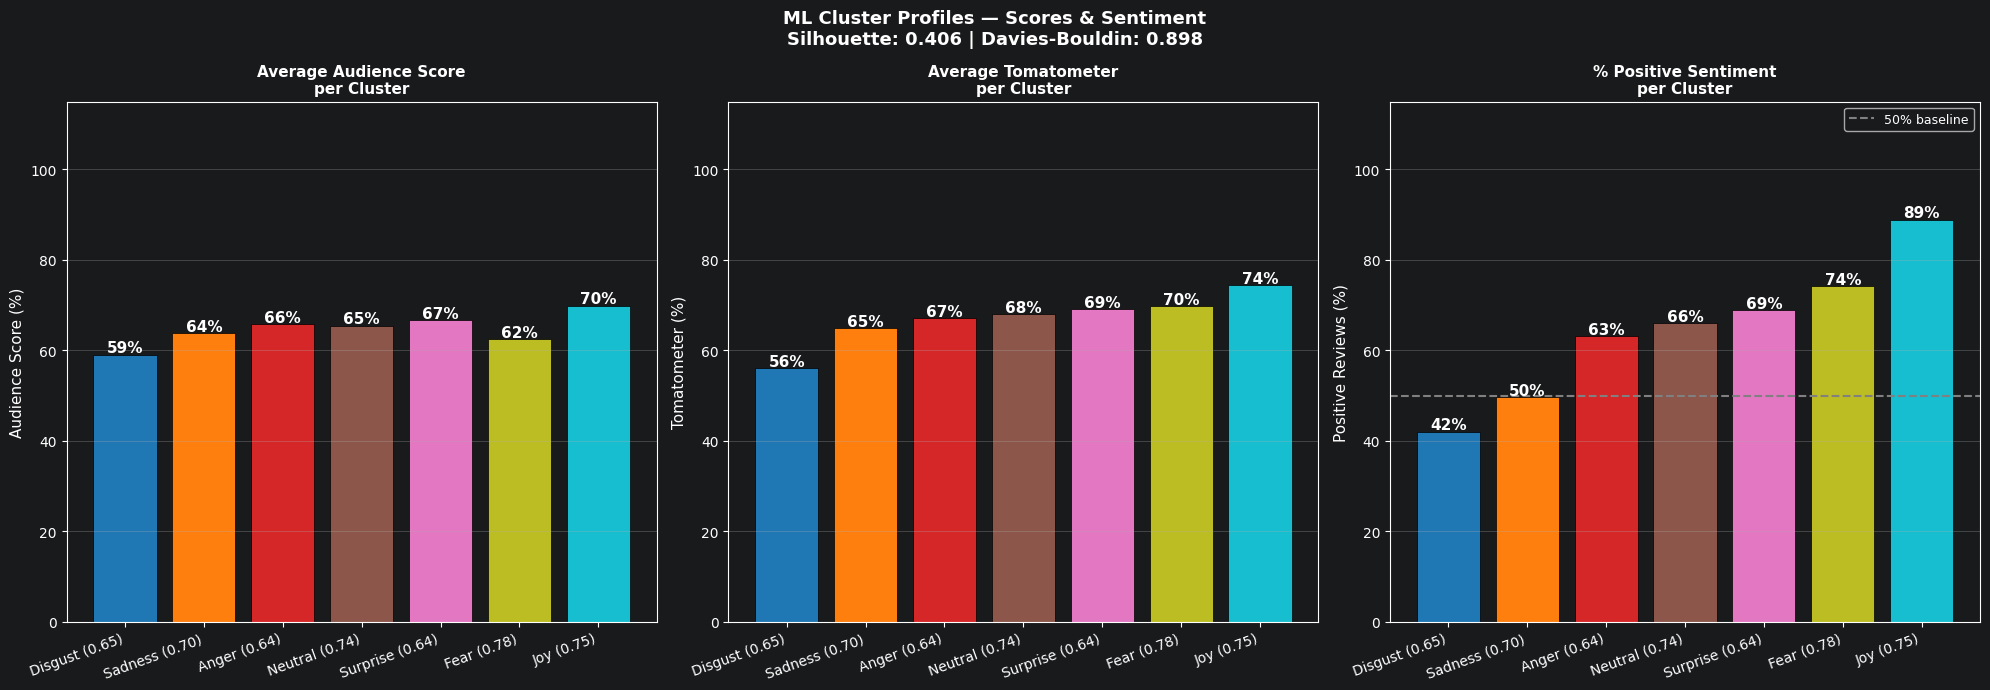

In [118]:
print(" Plot 5: Cluster Profiles ")
aud_vals = [df[df["cluster_name"] == c]["audienceScore"].mean()
            for c in cluster_order]
tom_vals = [df[df["cluster_name"] == c]["tomatoMeter"].mean()
            for c in cluster_order]
pos_vals = [100 * (df[df["cluster_name"] == c]["scoreSentiment"] == "POSITIVE").mean()
            for c in cluster_order]
xticklabels = [c.split("\n")[0] for c in cluster_order]
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
for ax, vals, title, ylabel in zip(
        axes,
        [aud_vals, tom_vals, pos_vals],
        ["Average Audience Score\nper Cluster",
         "Average Tomatometer\nper Cluster",
         "% Positive Sentiment\nper Cluster"],
        ["Audience Score (%)", "Tomatometer (%)", "Positive Reviews (%)"]):

    bars = ax.bar(range(len(cluster_order)), vals,
                  color=cluster_colors, edgecolor="black", linewidth=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f"{val:.0f}%", ha="center", fontweight="bold", fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontweight="bold", fontsize=11)
    ax.set_ylim(0, 115)
    ax.set_xticks(range(len(cluster_order)))
    ax.set_xticklabels(xticklabels, rotation=20, ha="right", fontsize=10)
    ax.grid(axis="y", alpha=0.4)
    if "Sentiment" in title:
        ax.axhline(50, color="gray", linestyle="--",
                   linewidth=1.5, label="50% baseline")
        ax.legend(fontsize=9)
fig.suptitle(f"ML Cluster Profiles — Scores & Sentiment\n"
             f"Silhouette: {sil_final:.3f} | Davies-Bouldin: {db_final:.3f}",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("plot6_cluster_profiles.png", dpi=150, bbox_inches="tight")
plt.show()


# Plot 6 : Box plots

 Plot 6: Box Plots 


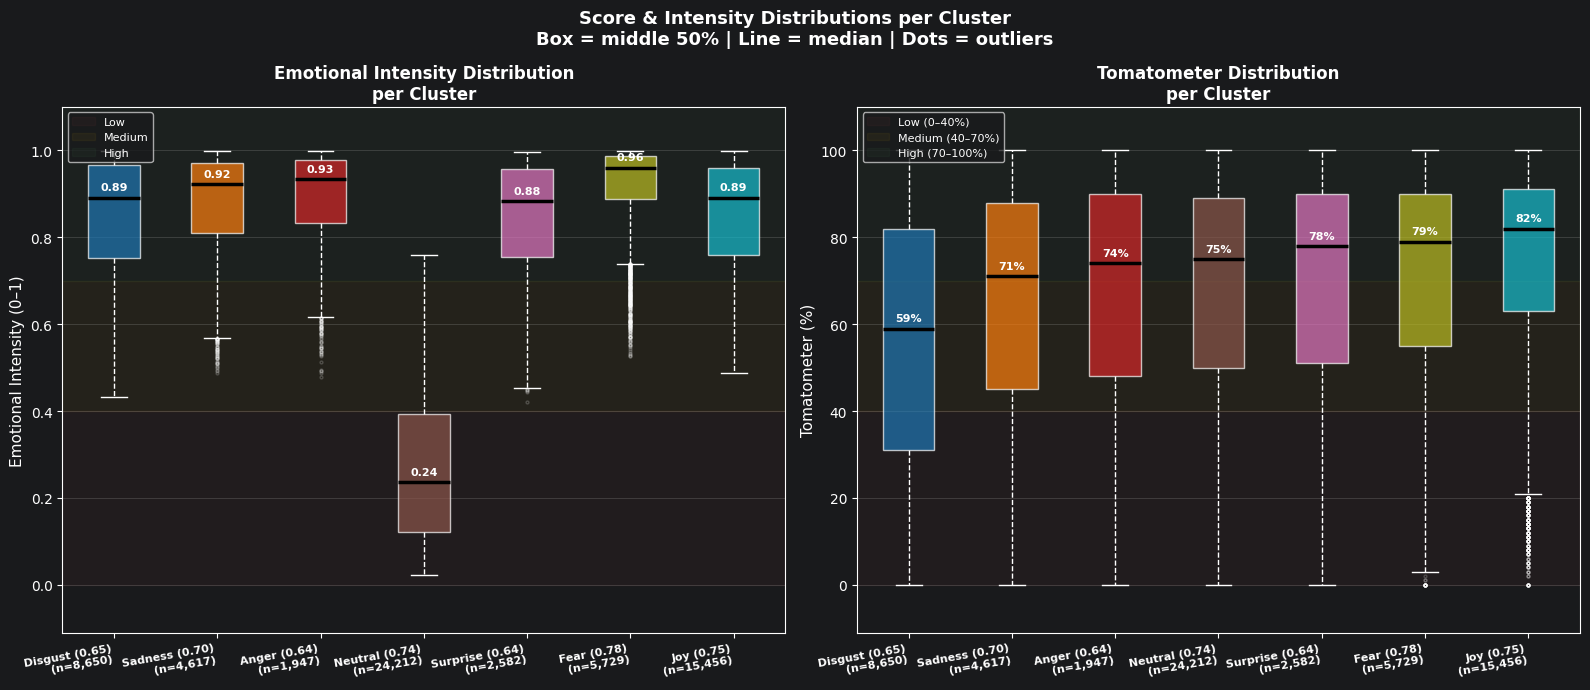

In [119]:
print(" Plot 6: Box Plots ")
data_ei = [df[df["cluster_name"] == c]["emotional_intensity"].values
           for c in cluster_order]
data_tom = [df[df["cluster_name"] == c]["tomatoMeter"].values
            for c in cluster_order]
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, data, title, ylabel, ymax, fmt in zip(
        axes,
        [data_ei, data_tom],
        ["Emotional Intensity Distribution\nper Cluster",
         "Tomatometer Distribution\nper Cluster"],
        ["Emotional Intensity (0–1)", "Tomatometer (%)"],
        [1.1, 110],
        [".2f", ".0f"]):

    bp = ax.boxplot(data, patch_artist=True, notch=False,
                    medianprops=dict(color="black", linewidth=2.5),
                    flierprops=dict(marker='o', markersize=2, alpha=0.2))

    for patch, color in zip(bp["boxes"], cluster_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    for whisker in bp["whiskers"]:
        whisker.set_linestyle("--")

    if ymax > 2:
        ax.axhspan(0, 40, alpha=0.05, color="#C44E52", label="Low (0–40%)")
        ax.axhspan(40, 70, alpha=0.05, color="#F5C518", label="Medium (40–70%)")
        ax.axhspan(70, 110, alpha=0.05, color="#55A868", label="High (70–100%)")
    else:
        ax.axhspan(0, 0.4, alpha=0.05, color="#C44E52", label="Low")
        ax.axhspan(0.4, 0.7, alpha=0.05, color="#F5C518", label="Medium")
        ax.axhspan(0.7, 1.1, alpha=0.05, color="#55A868", label="High")

    for i, (d, c) in enumerate(zip(data, cluster_order)):
        median = np.median(d)
        label = f"{median:{fmt}}" if fmt == ".2f" else f"{median:.0f}%"
        ax.text(i + 1, median + ymax * 0.015, label,
                ha="center", fontsize=8, fontweight="bold")

    xlabels = [f"{c.split(chr(10))[0]}\n(n={(df['cluster_name'] == c).sum():,})"
               for c in cluster_order]
    ax.set_xticks(range(1, len(cluster_order) + 1))
    ax.set_xticklabels(xlabels, rotation=10, ha="right",
                       fontsize=8, fontweight="bold")
    ax.set_title(title, fontweight="bold", fontsize=12)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_ylim(-ymax * 0.1, ymax)
    ax.grid(axis="y", alpha=0.3)
    ax.legend(fontsize=8, loc="upper left")
fig.suptitle("Score & Intensity Distributions per Cluster\n"
             "Box = middle 50% | Line = median | Dots = outliers",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("plot7_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

### Beispielinstanzen pro Cluster 

In [120]:
# Beispielinstanzen pro Cluster
print(" Beispielinstanzen ")
emotions_plot = ["joy", "anger", "sadness", "fear", "disgust", "surprise", "neutral"]

for cluster_name in cluster_order:
    example = df[df["cluster_name"] == cluster_name].sample(1, random_state=42)
    dom_emotion = emotions_plot[example[emotions_plot].values[0].argmax()]
    print(f"Cluster: {cluster_name}")
    print(f"  Review:       {example['reviewText'].values[0][:200]}")
    print(f"  Tomatometer:  {example['tomatoMeter'].values[0]:.0f}%")
    print(f"  Dom. Emotion: {dom_emotion}")
    print()

 Beispielinstanzen 
Cluster: Disgust (0.65)
Mixed | High Intensity
Tomato: 56%
  Review:       Cringe-inducing debauchery courtesy of The Godfather of Rap!
  Tomatometer:  63%
  Dom. Emotion: disgust

Cluster: Sadness (0.70)
Mixed | High Intensity
Tomato: 65%
  Review:       an exceedingly well detailed, but emotionally bereft recreation of a bygone era
  Tomatometer:  92%
  Dom. Emotion: sadness

Cluster: Anger (0.64)
Positive | High Intensity
Tomato: 67%
  Review:       Believe all the hype: This movie will melt your face off.
  Tomatometer:  97%
  Dom. Emotion: anger

Cluster: Neutral (0.74)
Positive | Low Intensity
Tomato: 68%
  Review:       A-list Hollywood stars have zero chemistry in an utterly tiresome and contrived heist flick. Red Notice ends up looking like nothing more than flashy costume jewelry.
  Tomatometer:  36%
  Dom. Emotion: neutral

Cluster: Surprise (0.64)
Positive | High Intensity
Tomato: 69%
  Review:       An unexpectedly stirring first feature by Kyle Patrick

# Vergleich Mit und Ohne Emotional Intensity

In [121]:
feature_cols_with    = ["joy", "anger", "sadness", "fear", "disgust", "surprise","neutral", "emotional_intensity", "audienceScore", "tomatoMeter"]
feature_cols_without = ["joy", "anger", "sadness", "fear", "disgust", "surprise", "neutral", "audienceScore", "tomatoMeter"]

print(" Vergleich: Mit vs Ohne emotional_intensity ")
results = {}

for label, cols in [("MIT emotional_intensity",   feature_cols_with),
                    ("OHNE emotional_intensity",   feature_cols_without)]:
    print(f"  Berechne: {label} ({len(cols)} Features)...")
    X_test        = df[cols].values
    X_test_scaled = StandardScaler().fit_transform(X_test)
    mbk_test      = MiniBatchKMeans(n_clusters=7, random_state=42,
                                     batch_size=10000, n_init=10)
    labels_test   = mbk_test.fit_predict(X_test_scaled)
    sil_test      = silhouette_score(X_test_scaled, labels_test, sample_size=5000)
    results[label] = sil_test
    print(f"  {label}: Silhouette = {sil_test:.3f} | Features: {cols}")

print(f"\nErgebnis:")
for label, sil in results.items():
    print(f"  {label}: {sil:.3f}")

diff = results["MIT emotional_intensity"] - results["OHNE emotional_intensity"]
print(f"\n→ Verbesserung durch emotional_intensity: +{diff:.3f}")
print(f"→ emotional_intensity wird beibehalten da es die Clusterqualität messbar verbessert")

 Vergleich: Mit vs Ohne emotional_intensity 
  Berechne: MIT emotional_intensity (10 Features)...
  MIT emotional_intensity: Silhouette = 0.412 | Features: ['joy', 'anger', 'sadness', 'fear', 'disgust', 'surprise', 'neutral', 'emotional_intensity', 'audienceScore', 'tomatoMeter']
  Berechne: OHNE emotional_intensity (9 Features)...
  OHNE emotional_intensity: Silhouette = 0.374 | Features: ['joy', 'anger', 'sadness', 'fear', 'disgust', 'surprise', 'neutral', 'audienceScore', 'tomatoMeter']

Ergebnis:
  MIT emotional_intensity: 0.412
  OHNE emotional_intensity: 0.374

→ Verbesserung durch emotional_intensity: +0.038
→ emotional_intensity wird beibehalten da es die Clusterqualität messbar verbessert


# Summary

In [122]:
print(" " + "=" * 60)
print("COMPLETE CLUSTERING SUMMARY")

COMPLETE CLUSTERING SUMMARY


In [123]:
print("PART 1: Genre based Emotion Analysis ")
print(f"Total reviews: {len(df):,}")
print(f"Top emotion per genre:")
for g in genre_list:
    dom = genre_emotion.loc[g].idxmax()
    val = genre_emotion.loc[g].max()
    tom = genre_scores[genre_scores["main_genre"] == g]["tomatoMeter"].values[0]
    pos = genre_scores[genre_scores["main_genre"] == g]["positive_pct"].values[0]
    print(f"  {g}: dominant={dom} ({val:.3f}) | tomato={tom:.0f}% | positive={pos:.0f}%")

PART 1: Genre based Emotion Analysis 
Total reviews: 63,193
Top emotion per genre:
  Action: dominant=joy (0.251) | tomato=58% | positive=58%
  Comedy: dominant=joy (0.294) | tomato=63% | positive=63%
  Documentary: dominant=joy (0.218) | tomato=86% | positive=86%
  Drama: dominant=joy (0.210) | tomato=73% | positive=73%
  Horror: dominant=fear (0.291) | tomato=60% | positive=61%
  Mystery & thriller: dominant=joy (0.179) | tomato=62% | positive=61%


In [124]:
print(" PART 2: ML Clustering")
print(f"Algorithm:       MiniBatchKMeans")
print(f"Features:        {feature_cols}")
print(f"Best k:          {best_k}")
print(f"Silhouette:      {sil_final:.3f}")
print(f"Davies-Bouldin:  {db_final:.3f}")
print(f"Cluster profiles:")
for cname in cluster_order:
    n = (df["cluster_name"] == cname).sum()
    tom = df[df["cluster_name"] == cname]["tomatoMeter"].mean()
    pos = 100 * (df[df["cluster_name"] == cname]["scoreSentiment"] == "POSITIVE").mean()
    ei = df[df["cluster_name"] == cname]["emotional_intensity"].mean()
    print(f"  {cname.split(chr(10))[0]}: "
          f"n={n:,} | tomato={tom:.0f}% | positive={pos:.0f}% | intensity={ei:.3f}")

 PART 2: ML Clustering
Algorithm:       MiniBatchKMeans
Features:        ['joy', 'anger', 'sadness', 'fear', 'disgust', 'surprise', 'neutral', 'emotional_intensity', 'audienceScore', 'tomatoMeter']
Best k:          7
Silhouette:      0.406
Davies-Bouldin:  0.898
Cluster profiles:
  Disgust (0.65): n=8,650 | tomato=56% | positive=42% | intensity=0.850
  Sadness (0.70): n=4,617 | tomato=65% | positive=50% | intensity=0.878
  Anger (0.64): n=1,947 | tomato=67% | positive=63% | intensity=0.889
  Neutral (0.74): n=24,212 | tomato=68% | positive=66% | intensity=0.264
  Surprise (0.64): n=2,582 | tomato=69% | positive=69% | intensity=0.843
  Fear (0.78): n=5,729 | tomato=70% | positive=74% | intensity=0.919
  Joy (0.75): n=15,456 | tomato=74% | positive=89% | intensity=0.849


In [125]:
print(df["cluster"].value_counts())
print(df["cluster_name"].value_counts())

cluster
4    24212
1    15456
3     8650
2     5729
5     4617
6     2582
7     1947
Name: count, dtype: int64
cluster_name
Neutral (0.74)\nPositive | Low Intensity\nTomato: 68%      24212
Joy (0.75)\nPositive | High Intensity\nTomato: 74%         15456
Disgust (0.65)\nMixed | High Intensity\nTomato: 56%         8650
Fear (0.78)\nPositive | High Intensity\nTomato: 70%         5729
Sadness (0.70)\nMixed | High Intensity\nTomato: 65%         4617
Surprise (0.64)\nPositive | High Intensity\nTomato: 69%     2582
Anger (0.64)\nPositive | High Intensity\nTomato: 67%        1947
Name: count, dtype: int64


# Modell 3 : Emotionsmuster und Outliererkennung mit DBSCAN

In [126]:
print("Loading datasets...")
emotions = pd.read_csv(DATA_DIR / "classification_sample_100k_with_emotions.csv")
merged = pd.read_csv(DATA_DIR / "merged_clean.csv")

merged["main_genre"] = merged["genre"].str.split(",").str[0].str.strip()
top_genres = merged["main_genre"].value_counts().head(6).index
merged = merged[merged["main_genre"].isin(top_genres)]

df = emotions.merge(
    merged[["reviewId", "main_genre", "audienceScore", "tomatoMeter"]],
    on="reviewId", how="inner")
df = df.dropna(subset=["joy", "anger", "sadness", "fear",
                       "disgust", "surprise", "neutral",
                       "emotional_intensity", "audienceScore",
                       "tomatoMeter", "main_genre"]).reset_index(drop=True)

print(f"Dataset: {len(df):,} reviews")


Loading datasets...
Dataset: 63,193 reviews


In [127]:

print(""" DBSCAN unterscheidet sich von KMeans:

KMeans:   - Anzahl Cluster muss vorher festgelegt werden (k=7)
           - Jeder Punkt wird einem Cluster zugewiesen
           - Findet nur kugelförmige Cluster

DBSCAN:   - Anzahl Cluster wird automatisch aus den Daten bestimmt
           - Punkte die zu keinem Cluster gehören werden als
             OUTLIER markiert → Label = -1
           - Findet Cluster beliebiger Form
           - Besonders gut für: ungewöhnliche Reviews entdecken
""")

 DBSCAN unterscheidet sich von KMeans:

KMeans:   - Anzahl Cluster muss vorher festgelegt werden (k=7)
           - Jeder Punkt wird einem Cluster zugewiesen
           - Findet nur kugelförmige Cluster

DBSCAN:   - Anzahl Cluster wird automatisch aus den Daten bestimmt
           - Punkte die zu keinem Cluster gehören werden als
             OUTLIER markiert → Label = -1
           - Findet Cluster beliebiger Form
           - Besonders gut für: ungewöhnliche Reviews entdecken



In [128]:
feature_cols = ["joy", "anger", "sadness", "fear",
                "disgust", "surprise", "neutral", "emotional_intensity"]

sample_size = 8000
df_sample   = df.sample(n=sample_size, random_state=42).reset_index(drop=True)

X        = df_sample[feature_cols].values
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Sample: {sample_size:,} reviews")
print(f"Features (nur Emotionen): {feature_cols}")
print("Bewusst OHNE audienceScore/tomatoMeter um rein emotionale")
print("Muster zu finden — unabhängig von der Filmbewertung")


Sample: 8,000 reviews
Features (nur Emotionen): ['joy', 'anger', 'sadness', 'fear', 'disgust', 'surprise', 'neutral', 'emotional_intensity']
Bewusst OHNE audienceScore/tomatoMeter um rein emotionale
Muster zu finden — unabhängig von der Filmbewertung


 DBSCAN Parameter Tuning 
Testen verschiedener eps-Werte um optimale Cluster zu finden...
  eps=0.3: 8 Cluster | 2860 Outlier (35.8%) | Silhouette=0.268
  eps=0.5: 5 Cluster | 1373 Outlier (17.2%) | Silhouette=0.431
  eps=0.7: 2 Cluster | 423 Outlier (5.3%) | Silhouette=0.510
  eps=0.9: 2 Cluster | 128 Outlier (1.6%) | Silhouette=0.141
  eps=1.1: 1 Cluster | 48 Outlier (0.6%) | Silhouette=-1.000
  eps=1.3: 1 Cluster | 8 Outlier (0.1%) | Silhouette=-1.000

→ Bestes eps = 0.7


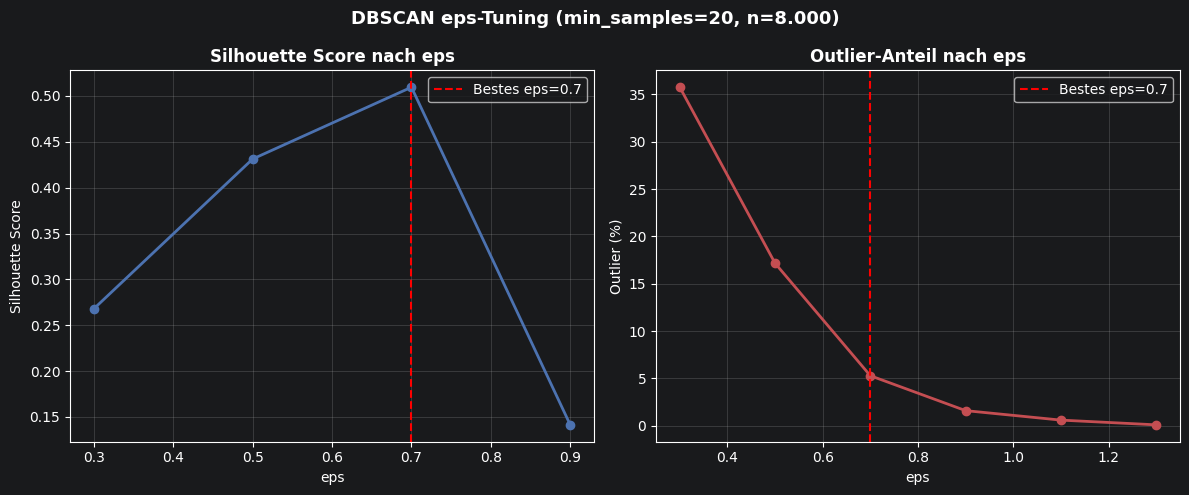

In [129]:
print(" DBSCAN Parameter Tuning ")
print("Testen verschiedener eps-Werte um optimale Cluster zu finden...")

results = []
for eps in [0.3, 0.5, 0.7, 0.9, 1.1, 1.3]:
    db       = DBSCAN(eps=eps, min_samples=20)
    labels   = db.fit_predict(X_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_outliers = (labels == -1).sum()
    outlier_pct = 100 * n_outliers / len(labels)

    if n_clusters >= 2:
        sil = silhouette_score(X_scaled[labels != -1],
                               labels[labels != -1],
                               sample_size=min(3000, (labels != -1).sum()))
    else:
        sil = -1

    results.append({
        'eps': eps,
        'n_clusters': n_clusters,
        'n_outliers': n_outliers,
        'outlier_pct': outlier_pct,
        'silhouette': sil
    })
    print(f"  eps={eps}: {n_clusters} Cluster | "
          f"{n_outliers} Outlier ({outlier_pct:.1f}%) | "
          f"Silhouette={sil:.3f}")


results_df = pd.DataFrame(results)
valid      = results_df[results_df["n_clusters"] >= 2]
if valid.empty:
    print("\n⚠️ Kein eps-Wert hat 2+ Cluster gefunden.")
    print("→ Versuche größere eps-Werte oder reduziere min_samples")
    print("\nAlle Ergebnisse:")
    print(results_df.to_string(index=False))
    best_eps = None
else:
    best_eps = valid.loc[valid["silhouette"].idxmax(), "eps"]
    print(f"\n→ Bestes eps = {best_eps}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

eps_vals   = results_df["eps"]
sil_vals   = results_df["silhouette"].replace(-1, None)
out_vals   = results_df["outlier_pct"]

ax1.plot(eps_vals, sil_vals, marker="o", color="#4C72B0", linewidth=2)
ax1.axvline(x=best_eps, color="red", linestyle="--", label=f"Bestes eps={best_eps}")
ax1.set_title("Silhouette Score nach eps", fontweight="bold")
ax1.set_xlabel("eps")
ax1.set_ylabel("Silhouette Score")
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(eps_vals, out_vals, marker="o", color="#C44E52", linewidth=2)
ax2.axvline(x=best_eps, color="red", linestyle="--", label=f"Bestes eps={best_eps}")
ax2.set_title("Outlier-Anteil nach eps", fontweight="bold")
ax2.set_xlabel("eps")
ax2.set_ylabel("Outlier (%)")
ax2.legend()
ax2.grid(alpha=0.3)

fig.suptitle("DBSCAN eps-Tuning (min_samples=20, n=8.000)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("plot_dbscan_eps_tuning.png", dpi=150, bbox_inches="tight")
plt.show()

In [130]:
print(f"\n--- Training DBSCAN (eps={best_eps}, min_samples=20) ---")

dbscan_final = DBSCAN(eps=best_eps, min_samples=20)
labels_final = dbscan_final.fit_predict(X_scaled)
df_sample["cluster_dbscan"] = labels_final

n_clusters  = len(set(labels_final)) - (1 if -1 in labels_final else 0)
n_outliers  = (labels_final == -1).sum()
n_core      = len(labels_final) - n_outliers

print(f"Gefundene Cluster: {n_clusters}")
print(f"Outlier (Rauschen): {n_outliers} ({100*n_outliers/len(labels_final):.1f}%)")
print(f"Clustered Reviews:  {n_core} ({100*n_core/len(labels_final):.1f}%)")

if n_clusters >= 2:
    mask_valid = labels_final != -1
    sil_final  = silhouette_score(X_scaled[mask_valid],
                                   labels_final[mask_valid],
                                   sample_size=min(3000, mask_valid.sum()))
    print(f"Silhouette Score (ohne Outlier): {sil_final:.3f}")

# Cluster Profile
print("\nCluster Profile:")
emotions_plot = ["joy","anger","sadness","fear","disgust","surprise","neutral"]
cluster_ids   = sorted([c for c in set(labels_final) if c != -1])

cluster_name_map = {}
for cid in cluster_ids:
    mask    = df_sample["cluster_dbscan"] == cid
    subset  = df_sample[mask]
    dom_em  = subset[emotions_plot].mean().idxmax()
    dom_val = subset[emotions_plot].mean().max()
    tom     = subset["tomatoMeter"].mean()
    ei      = subset["emotional_intensity"].mean()
    n       = mask.sum()
    cluster_name_map[cid] = f"{dom_em.capitalize()} ({dom_val:.2f})"
    print(f"  Cluster {cid}: dominant={dom_em} ({dom_val:.3f}) | "
          f"tomato={tom:.0f}% | intensity={ei:.3f} | n={n}")

print(f"\n  Outlier (kein Cluster): n={n_outliers}")
print(f"  → Reviews die keinem emotionalen Muster entsprechen")


--- Training DBSCAN (eps=0.7, min_samples=20) ---
Gefundene Cluster: 2
Outlier (Rauschen): 423 (5.3%)
Clustered Reviews:  7577 (94.7%)
Silhouette Score (ohne Outlier): 0.479

Cluster Profile:
  Cluster 0: dominant=neutral (0.382) | tomato=68% | intensity=0.618 | n=7399
  Cluster 1: dominant=anger (0.763) | tomato=68% | intensity=0.902 | n=178

  Outlier (kein Cluster): n=423
  → Reviews die keinem emotionalen Muster entsprechen


# Plot 1 : Cluster vs Outlier

 Plot 1: Cluster und Outlier 


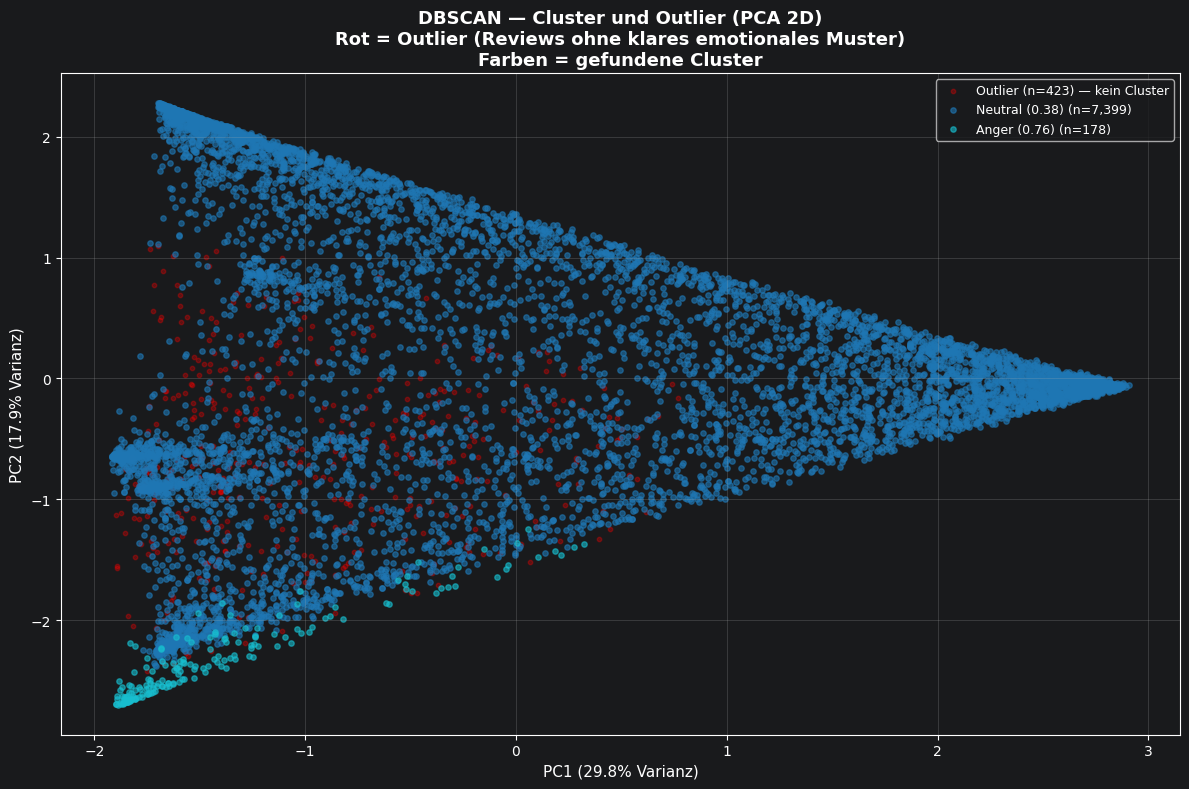

In [131]:
print(" Plot 1: Cluster und Outlier ")

pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
var   = pca.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(12, 8))

mask_out = labels_final == -1
ax.scatter(X_pca[mask_out, 0], X_pca[mask_out, 1],
           c="red", alpha=0.3, s=10,
           label=f"Outlier (n={mask_out.sum():,}) — kein Cluster")


colors_dbscan = plt.cm.tab10(np.linspace(0, 1, max(len(cluster_ids), 2)))
for i, cid in enumerate(cluster_ids):
    mask = labels_final == cid
    name = cluster_name_map.get(cid, f"Cluster {cid}")
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=[colors_dbscan[i]], alpha=0.6, s=15,
               label=f"{name} (n={mask.sum():,})")

ax.set_title("DBSCAN — Cluster und Outlier (PCA 2D)\n"
             "Rot = Outlier (Reviews ohne klares emotionales Muster)\n"
             "Farben = gefundene Cluster",
             fontweight="bold", fontsize=13)
ax.set_xlabel(f"PC1 ({var[0]*100:.1f}% Varianz)", fontsize=11)
ax.set_ylabel(f"PC2 ({var[1]*100:.1f}% Varianz)", fontsize=11)
ax.legend(fontsize=9, loc="upper right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("plot_dbscan_pca.png", dpi=150, bbox_inches="tight")
plt.show()

# Plot 2: Outlier Analyse

Plot 2: Outlier Analyse 


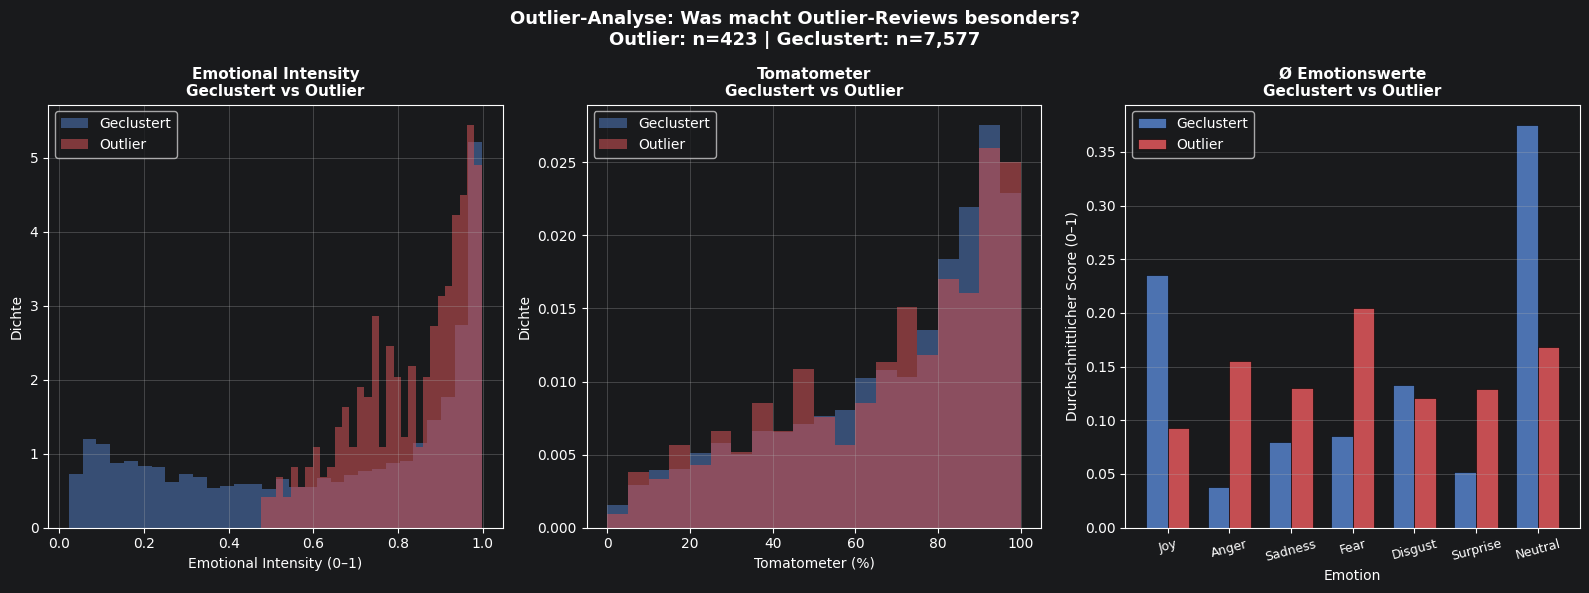

In [132]:
print("Plot 2: Outlier Analyse ")

df_outlier  = df_sample[df_sample["cluster_dbscan"] == -1]
df_clustered = df_sample[df_sample["cluster_dbscan"] != -1]

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# Emotional Intensity
axes[0].hist(df_clustered["emotional_intensity"], bins=30,
             alpha=0.6, color="#4C72B0", label="Geclustert", density=True)
axes[0].hist(df_outlier["emotional_intensity"], bins=30,
             alpha=0.6, color="#C44E52", label="Outlier", density=True)
axes[0].set_title("Emotional Intensity\nGeclustert vs Outlier",
                  fontweight="bold", fontsize=11)
axes[0].set_xlabel("Emotional Intensity (0–1)")
axes[0].set_ylabel("Dichte")
axes[0].legend()
axes[0].grid(alpha=0.4)

# Tomatometer
axes[1].hist(df_clustered["tomatoMeter"], bins=20,
             alpha=0.6, color="#4C72B0", label="Geclustert", density=True)
axes[1].hist(df_outlier["tomatoMeter"], bins=20,
             alpha=0.6, color="#C44E52", label="Outlier", density=True)
axes[1].set_title("Tomatometer\nGeclustert vs Outlier",
                  fontweight="bold", fontsize=11)
axes[1].set_xlabel("Tomatometer (%)")
axes[1].set_ylabel("Dichte")
axes[1].legend()
axes[1].grid(alpha=0.4)

# Emotion Scores Vergleich
em_means_clustered = df_clustered[emotions_plot].mean()
em_means_outlier   = df_outlier[emotions_plot].mean()

x     = np.arange(len(emotions_plot))
width = 0.35
axes[2].bar(x - width/2, em_means_clustered, width,
            label="Geclustert", color="#4C72B0",
            edgecolor="black", linewidth=0.4)
axes[2].bar(x + width/2, em_means_outlier, width,
            label="Outlier", color="#C44E52",
            edgecolor="black", linewidth=0.4)
axes[2].set_title("Ø Emotionswerte\nGeclustert vs Outlier",
                  fontweight="bold", fontsize=11)
axes[2].set_xlabel("Emotion")
axes[2].set_ylabel("Durchschnittlicher Score (0–1)")
axes[2].set_xticks(x)
axes[2].set_xticklabels([e.capitalize() for e in emotions_plot],
                         rotation=15, fontsize=9)
axes[2].legend()
axes[2].grid(axis="y", alpha=0.4)

fig.suptitle("Outlier-Analyse: Was macht Outlier-Reviews besonders?\n"
             f"Outlier: n={len(df_outlier):,} | "
             f"Geclustert: n={len(df_clustered):,}",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("plot_dbscan_outlier.png", dpi=150, bbox_inches="tight")
plt.show()

# Plot 3: MiniBatchKMeans vs DBSCAN

 Plot 3: DBSCAN vs KMeans Vergleich 


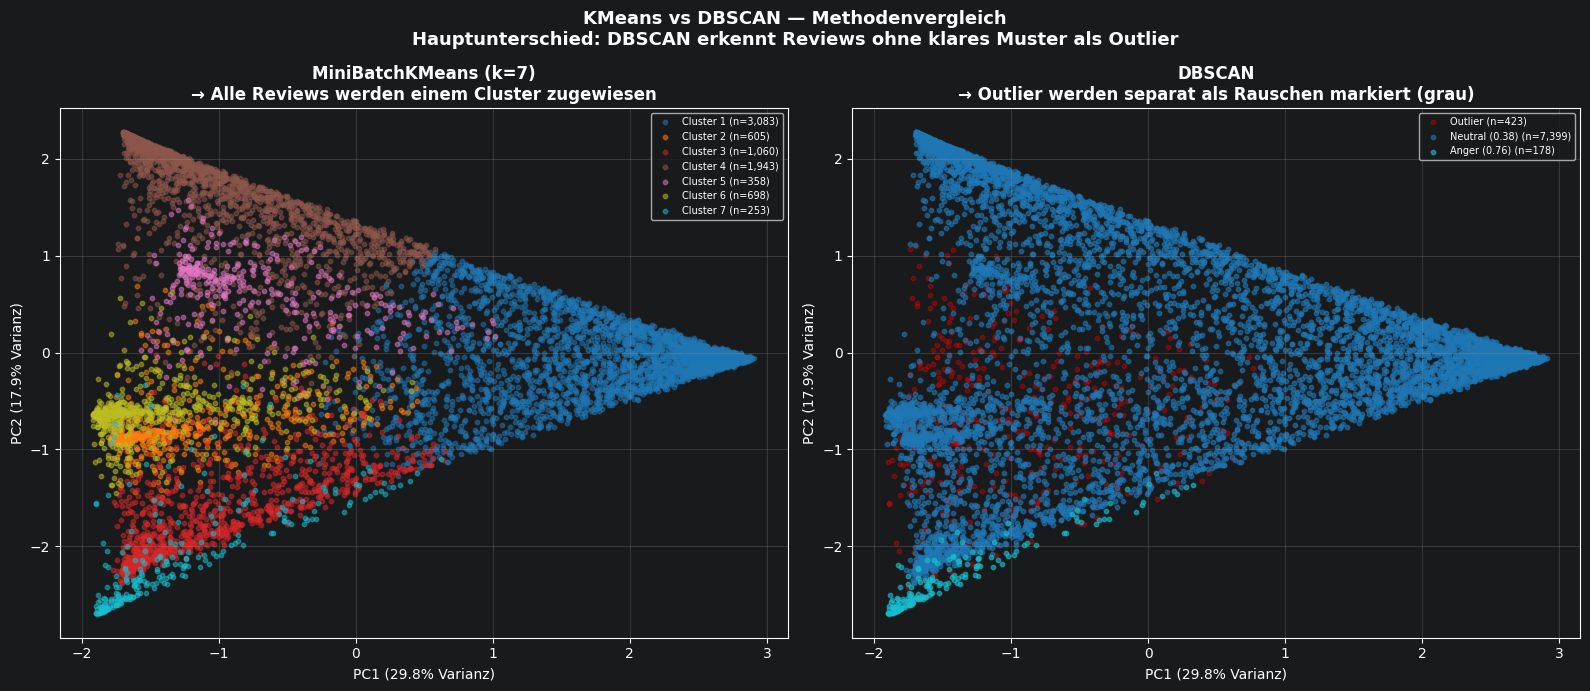

In [133]:
print(" Plot 3: DBSCAN vs KMeans Vergleich ")
from sklearn.cluster import MiniBatchKMeans
mbk_comp   = MiniBatchKMeans(n_clusters=7, random_state=42,
                              batch_size=1000, n_init=10)
labels_mbk = mbk_comp.fit_predict(X_scaled)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))


colors_mbk = plt.cm.tab10(np.linspace(0, 1, 7))
for i in range(7):
    mask = labels_mbk == i
    ax1.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=[colors_mbk[i]], alpha=0.5, s=10,
                label=f"Cluster {i+1} (n={mask.sum():,})")
ax1.set_title("MiniBatchKMeans (k=7)\n"
              "→ Alle Reviews werden einem Cluster zugewiesen",
              fontweight="bold", fontsize=12)
ax1.set_xlabel(f"PC1 ({var[0]*100:.1f}% Varianz)", fontsize=10)
ax1.set_ylabel(f"PC2 ({var[1]*100:.1f}% Varianz)", fontsize=10)
ax1.legend(fontsize=7, loc="upper right")
ax1.grid(alpha=0.3)


ax2.scatter(X_pca[mask_out, 0], X_pca[mask_out, 1],
            c="red", alpha=0.3, s=10,
            label=f"Outlier (n={mask_out.sum():,})")
for i, cid in enumerate(cluster_ids):
    mask = labels_final == cid
    name = cluster_name_map.get(cid, f"Cluster {cid}")
    ax2.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=[colors_dbscan[i]], alpha=0.6, s=10,
                label=f"{name} (n={mask.sum():,})")
ax2.set_title("DBSCAN\n"
              "→ Outlier werden separat als Rauschen markiert (grau)",
              fontweight="bold", fontsize=12)
ax2.set_xlabel(f"PC1 ({var[0]*100:.1f}% Varianz)", fontsize=10)
ax2.set_ylabel(f"PC2 ({var[1]*100:.1f}% Varianz)", fontsize=10)
ax2.legend(fontsize=7, loc="upper right")
ax2.grid(alpha=0.3)

fig.suptitle("KMeans vs DBSCAN — Methodenvergleich\n"
             "Hauptunterschied: DBSCAN erkennt Reviews ohne klares Muster als Outlier",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("plot_dbscan_vergleich.png", dpi=150, bbox_inches="tight")
plt.show()

# Summary

In [134]:
print("" + "="*60)
print("DBSCAN CLUSTERING SUMMARY")
print(f"""
Algorithmus:      DBSCAN (Density-Based Spatial Clustering)
Sample:           {sample_size:,} Reviews
Features:         {feature_cols}
                  (bewusst OHNE audienceScore/tomatoMeter)
eps:              {best_eps}
min_samples:      20

Ergebnis:
  Gefundene Cluster:  {n_clusters}
  Outlier:            {n_outliers} ({100*n_outliers/len(labels_final):.1f}%)
  Geclustert:         {n_core} ({100*n_core/len(labels_final):.1f}%)
  Silhouette:         {sil_final:.3f}

Warum DBSCAN anders als Modell 1 und 2:
  - Kein k vorab definiert → Cluster-Anzahl aus Daten bestimmt
  - Outlier werden explizit markiert → Reviews ohne klares Muster
  - Nur Emotionsfeatures → rein emotionale Muster ohne Score-Einfluss
  - Findet Cluster beliebiger Form, nicht nur kugelförmige

Warum MiniBatchKMeans als Hauptmodell bleibt:
  - DBSCAN skaliert nicht auf {len(df):,} Reviews
  - DBSCAN sensitiv gegenüber eps-Parameter
  - KMeans liefert stabilere, vergleichbare Cluster
 Done! 3 Plots saved.
""")

DBSCAN CLUSTERING SUMMARY

Algorithmus:      DBSCAN (Density-Based Spatial Clustering)
Sample:           8,000 Reviews
Features:         ['joy', 'anger', 'sadness', 'fear', 'disgust', 'surprise', 'neutral', 'emotional_intensity']
                  (bewusst OHNE audienceScore/tomatoMeter)
eps:              0.7
min_samples:      20

Ergebnis:
  Gefundene Cluster:  2
  Outlier:            423 (5.3%)
  Geclustert:         7577 (94.7%)
  Silhouette:         0.479

Warum DBSCAN anders als Modell 1 und 2:
  - Kein k vorab definiert → Cluster-Anzahl aus Daten bestimmt
  - Outlier werden explizit markiert → Reviews ohne klares Muster
  - Nur Emotionsfeatures → rein emotionale Muster ohne Score-Einfluss
  - Findet Cluster beliebiger Form, nicht nur kugelförmige

Warum MiniBatchKMeans als Hauptmodell bleibt:
  - DBSCAN skaliert nicht auf 63,193 Reviews
  - DBSCAN sensitiv gegenüber eps-Parameter
  - KMeans liefert stabilere, vergleichbare Cluster
 Done! 3 Plots saved.

